In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

device = torch.device('cuda')

# include parent dir in python path
sys.path.append('/media/carsen/ssd1/github/oneshot')
from utils import data, metrics

data_path = '/media/carsen/ssd1/github/oneshot/data'
# data_path  = '/home/carsen/dm11_cluster/fengtongd/Desktop/approxineuro/data'
# change path to your own dm11 path
img_root = '/home/carsen/dm11_pachitariu/data/STIM/'
weight_path = '/home/carsen/dm11_cluster/fengtongd/Desktop/github/oneshot/weights'
# weight_path = '/home/carsen/dm11_cluster/fengtongd/Desktop/approxineuro/weights'

res_dict = {}
mouse_ids = [7,8,10,11,12]  # mice used for the main results

# fullmodel (medial + V1 trained together)
- FEV and FEVE plot 
- get the neruon indexes for medial and V1
- compare the pooling size of these two areas
- visualize the first layer
- save the indexes to the data file for further training the separate models

In [3]:
# load data
mouse_id = 7
depth_separable = True
pool = True
clamp = True
use_30k = False # use all data recorded (>30k) or only 30k, performance will decrease if use only 30k.
area = 0
# load images
if mouse_id in [10, 11]: crop=False
else: crop=True
img = data.load_images(img_root, file=os.path.join(img_root, data.img_file_name[mouse_id]), crop=crop)# xrange=[0,130])
nimg, Ly, Lx = img.shape
print('img: ', img.shape, img.min(), img.max(), img.dtype)

# load neurons
fname = '%s_nat30k_%s.npz'%(data.db[mouse_id]['mname'], data.db[mouse_id]['datexp'])
spks, istim_train, istim_test, xpos, ypos, spks_rep_all, iplanes = data.load_neurons(file_path = os.path.join(data_path, fname), mouse_id = mouse_id, fixtrain=use_30k)
n_stim, n_neurons = spks.shape
print('spks: ', spks.shape, spks.min(), spks.max())
print('spks_rep_all: ', len(spks_rep_all), spks_rep_all[0].shape)
print('istim_train: ', istim_train.shape, istim_train.min(), istim_train.max())
print('istim_test: ', istim_test.shape, istim_test.min(), istim_test.max())

# iplanes = res_dict['iplane'].astype(int).squeeze()
print('iplane:', iplanes.shape, iplanes.min(), iplanes.max())
ilayers = np.zeros(iplanes.shape)
ilayers[iplanes==0] = 2
ilayers[iplanes==1] = 1
ilayers[iplanes==2] = 2
ilayers[iplanes==3] = 1

# split train and validation set
itrain, ival = data.split_train_val(istim_train, train_frac=0.9)
print('itrain: ', itrain.shape, itrain.min(), itrain.max())
print('ival: ', ival.shape, ival.min(), ival.max())
spks, spks_rep_all = data.normalize_spks(spks, spks_rep_all, itrain)

# ineur = np.arange(0, n_neurons) #np.arange(0, n_neurons, 5)
from utils import metrics
test_fev = metrics.fev(spks_rep_all)
print('FEV (test): ', np.mean(test_fev))

ineur = np.where(test_fev > 0.15)[0] #np.arange(0, n_neurons, 5) #np.where(test_fev > 0.05)[0] #np.arange(0, n_neurons) #np.arange(0, 100)
print('ineur: ', ineur.shape, ineur.min(), ineur.max())
xpos = xpos[ineur]
ypos = ypos[ineur]
iv1, imedial = data.split_area(mouse_id, xpos, ypos, ineur)
if area == 1: # V1
    ineur = iv1
elif area == 2: # PM
    ineur = imedial
# ineur = np.arange(0, n_neurons) #np.where(test_fev > 0.05)[0] #np.arange(0, n_neurons) #np.arange(0, 100)
img_test = torch.from_numpy(img[istim_test]).to(device).unsqueeze(1)
print('img_test: ', img_test.shape, img_test.min(), img_test.max())
input_Ly, input_Lx = img_test.shape[-2:]

spks_train = torch.from_numpy(spks[itrain][:,ineur])
spks_val = torch.from_numpy(spks[ival][:,ineur]) 
spks_rep_all = [spks_rep_all[i][:,ineur] for i in range(len(spks_rep_all))]
print('spks_train: ', spks_train.shape, spks_train.min(), spks_train.max())
print('spks_val: ', spks_val.shape, spks_val.min(), spks_val.max())

res_dict['mouse_id'] = mouse_id
res_dict['ineur'] = ineur
iarea = np.zeros_like(ineur, dtype=np.int32)
iarea[imedial] = 1
res_dict['iarea'] = iarea
res_dict['ilayer'] = ilayers[ineur]
res_dict['xpos'] = xpos
res_dict['ypos'] = ypos
res_dict['FEV_all'] = test_fev
res_dict['FEV'] = test_fev[ineur]

if not mouse_id == 11:
    from utils import newstim
    dat_TL     = newstim.load_timeline(data.db[mouse_id])
    res_dict['speed'] = dat_TL['TL']['beh']['run_speed']

raw image shape:  (68032, 66, 264)
cropped image shape:  (68032, 66, 130)
image mean:  126.71216
image std:  61.42324
img:  (68032, 66, 130) -2.062935 2.088588 float32

loading activities from /media/carsen/ssd1/github/oneshot/data/FX41_nat30k_2025_01_23.npz
spks:  (18709, 5373) -1.110223e-16 4.6251273
spks_rep_all:  500 (7, 5373)
istim_train:  (18709,) 532 30031
istim_test:  (500,) 32 531
iplane: (5373,) 0 3

splitting training and validation set...
there is currently no randomness in this function now, please make sure the istim_train is in random order!
itrain:  (16838,)
ival:  (1871,)
itrain:  (16838,) 1 18708
ival:  (1871,) 0 18700

normalizing neural data...
FEV (test):  0.1411178
ineur:  (2068,) 3 5364
img_test:  torch.Size([500, 1, 66, 130]) tensor(-2.0629, device='cuda:0') tensor(2.0886, device='cuda:0')


ERROR:root:ERROR: MATLAB type not supported: internal.Serialport, (uint32)


spks_train:  torch.Size([16838, 2068]) tensor(-9.8165e-16) tensor(43.8227)
spks_val:  torch.Size([1871, 2068]) tensor(-6.2202e-16) tensor(36.6769)


ERROR:root:ERROR: MATLAB type not supported: icomm.mqtt.Client, (uint32)


In [4]:
# load FECV
# save_path = './result'
# neural_catvar_all = np.load(os.path.join(save_path, f'{data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]}_neural_FECV.npy'))
# res_dict['FECV'] = neural_catvar_all[ineur]

In [5]:
# load the models and get FEVE
# 64, 16-64, 16-64-64, 16-64-64-64 model result
from utils import model_builder

lrs = [0.006, 0.003, 0.003, 0.003]
weight_decay_cores = [0.1, 0.001, 0.003, 0.06]
l2_readouts = [0.001, 0.001, 0.1, 0.1]

nlayers = 2
nconv1 = 16
nconv2 = 320

model, in_channels = model_builder.build_model(NN=len(ineur), n_layers=nlayers, n_conv=nconv1, n_conv_mid=nconv2, pool=pool, depth_separable=depth_separable, input_Ly=input_Ly, input_Lx=input_Lx)
model_name = model_builder.create_model_name(data.mouse_names[mouse_id], data.exp_date[mouse_id], n_layers=nlayers, in_channels=in_channels, clamp=clamp, suffix='', ineuron=len(ineur), crop=crop)
# weight_path = './checkpoints/'
model_path = os.path.join(weight_path, 'fullmodel', data.mouse_names[mouse_id], model_name)
model = model.to(device)

model.load_state_dict(torch.load(model_path))
print('loaded model', model_path)

# test model
from utils import model_trainer
test_pred = model_trainer.test_epoch(model, img_test)

input shape of readout:  (320, 33, 65)
model name:  FX41_012325_2layer_16_320_clamp_sensorium_depthsep_pool_nneurons_2068.pt
loaded model /home/carsen/dm11_cluster/fengtongd/Desktop/github/oneshot/weights/fullmodel/FX41/FX41_012325_2layer_16_320_clamp_sensorium_depthsep_pool_nneurons_2068.pt


conv1_w:  (16, 25, 25) -1.2909725 1.9643258


Text(0.5, 0.98, 'mouse 8 conv1 weights')

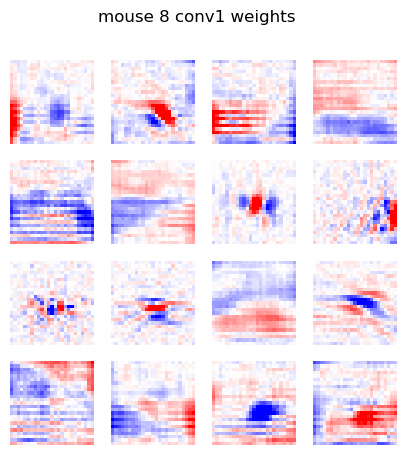

In [6]:
conv1_w = model.core.features.layer0.conv.weight.detach().cpu().numpy().squeeze()
print('conv1_w: ', conv1_w.shape, conv1_w.min(), conv1_w.max())

res_dict['conv1_w'] = conv1_w

fig, ax = plt.subplots(4, 4, figsize=(5,5))
for i in range(16):
    ax[i//4, i%4].imshow(conv1_w[i], cmap='bwr', vmin=-0.5, vmax=0.5)
    ax[i//4, i%4].axis('off')
plt.suptitle(f'mouse {mouse_id+1} conv1 weights')

In [7]:
test_fev, test_feve = metrics.feve_nan(spks_rep_all, test_pred)
# ivalid = np.where(test_fev > 0.15)[0]
# print(len(ivalid), ' neurons with FEV > 0.15')
print('FEVE (test): ', np.mean(test_feve))

res_dict['FEVE_fullmodel'] = test_feve

FEVE (test):  0.69944245


In [8]:
# FECV
save_path = './result'
fname = 'text16_%s_%s.npz'%(data.db[mouse_id]['mname'], data.db[mouse_id]['datexp'])
dat = np.load(os.path.join('../data', fname), allow_pickle=True)

txt16_spks_train = dat['sp'].T
# txt16_istim_train = dat['istim'].astype(int)
txt16_labels_train = dat['labels']
txt16_istim_train = dat['istim'].astype(int)


print('txt16_spks_train shape:', txt16_spks_train.shape)
print('txt16_labels_train shape:', txt16_labels_train.shape)
print('txt16_istim_train shape:', txt16_istim_train.shape)


txt16_spks_test_ori = dat['ss_all'] # each image has different reps
print('txt16_spks_test shape (nstim, nrep, nneuron):', txt16_spks_test_ori.shape)
# txt16_istim_test_ori = dat['ss_istim'].astype(int)
txt16_labels_test_ori = dat['ss_labels']
txt16_istim_test_ori = dat['ss_istim'].astype(int)

txt16_spks_test = []
txt16_labels_test = []
txt16_istim_test = []

for i in range(txt16_spks_test_ori.shape[0]):
    nrep = txt16_spks_test_ori[i].shape[0]
    txt16_spks_test.append(txt16_spks_test_ori[i])
    txt16_labels_test.append(np.repeat(txt16_labels_test_ori[i], nrep))
    txt16_istim_test.append(np.repeat(txt16_istim_test_ori[i], nrep))


txt16_spks_test = np.vstack(txt16_spks_test)
txt16_labels_test = np.hstack(txt16_labels_test)
txt16_istim_test = np.hstack(txt16_istim_test)

print('txt16_spks_test shape:', txt16_spks_test.shape)
print('txt16_labels_test shape:', txt16_labels_test.shape)
print('txt16_istim_test shape:', txt16_istim_test.shape)

txt16_spks = np.vstack((txt16_spks_train, txt16_spks_test)).astype(np.float32)
txt16_labels = np.hstack((txt16_labels_train, txt16_labels_test)).astype(int)
txt16_istim = np.hstack((txt16_istim_train, txt16_istim_test)) - 32

print('txt16_spks shape:', txt16_spks.shape)
print('txt16_labels shape:', txt16_labels.shape)
print('txt16_istim shape:', txt16_istim.shape)

from scipy.stats import zscore
txt16_spks = zscore(txt16_spks, axis=0)

from utils import metrics
neural_catvar_all = metrics.category_variance_pairwise(txt16_spks.T, txt16_labels)
print('neural_catvar_all shape:', neural_catvar_all.shape)

res_dict['FECV'] = neural_catvar_all[ineur]

txt16_spks_train shape: (3446, 5373)
txt16_labels_train shape: (3446,)
txt16_istim_train shape: (3446,)
txt16_spks_test shape (nstim, nrep, nneuron): (692,)
txt16_spks_test shape: (4664, 5373)
txt16_labels_test shape: (4664,)
txt16_istim_test shape: (4664,)
txt16_spks shape: (8110, 5373)
txt16_labels shape: (8110,)
txt16_istim shape: (8110,)
neural_catvar_all shape: (5373,)


In [9]:
# load txt16 images
data_path = '/home/carsen/dm11_pachitariu/data/STIM/'
if mouse_id in [10, 11]: crop=False
else: crop=True
img = data.load_images(data_path, file=os.path.join(data_path, 'nat60k_text16.mat'), normalize=False, crop=crop)# xrange=[0,130])
# img = data.load_images_mat(img_root, file='nat60k_text16.mat', downsample=1, normalize=True, crop=False, origin=True)[0]
print('img: ', img.shape, img.min(), img.max(), img.dtype)

txt16_img = img[txt16_istim]
print(txt16_img.shape, txt16_img.max(), txt16_img.min())

# zscore txt16_imgs
img_mean = txt16_img.mean()
img_std = txt16_img.std()
txt16_img_zscore = (txt16_img - img_mean) / img_std
print(txt16_img_zscore.shape, txt16_img_zscore.max(), txt16_img_zscore.min())
txt16_img_zscore = torch.from_numpy(txt16_img_zscore).unsqueeze(1)
print(txt16_img_zscore.shape)

# test model
model.eval()

# Define batch size (adjust based on GPU memory)
batch_size = 64

preds = []

with torch.no_grad():
    for i in range(0, txt16_img_zscore.size(0), batch_size):
        batch = txt16_img_zscore[i:i+batch_size].to(device)
        pred = model(batch)
        preds.append(pred.cpu())

# Concatenate all predictions
model_pred_all = torch.cat(preds, dim=0).numpy()

print('model_pred_all shape:', model_pred_all.shape)

raw image shape:  (68000, 66, 264)
cropped image shape:  (68000, 66, 130)
image mean:  126.71192
image std:  61.422768
img:  (68000, 66, 130) 0.0 255.0 float32
(8110, 66, 130) 255.0 0.0
(8110, 66, 130) 2.1027124 -2.062998
torch.Size([8110, 1, 66, 130])
model_pred_all shape: (8110, 2068)


In [10]:
model_catvar_all = metrics.category_variance_pairwise(model_pred_all.T, txt16_labels)
res_dict['FECV_model'] = model_catvar_all

/media/carsen/ssd1/github/oneshot/utils/metrics.py:194: RuntimeWarning: Mean of empty slice
  catvar_all = np.nanmean(np.stack(catvar_all), axis=0)


In [11]:
print(np.isnan(model_catvar_all).sum())
print('model_catvar_all shape:', model_catvar_all.shape)

1
model_catvar_all shape: (2068,)


In [12]:
# separate neurons
hmax_angle = 50
x_pixel_ratio = 0.5
y_pixel_ratio = 0.5
if mouse_id == 5:
    point1 = [-200, 0]
    point2 = [-500, 600]
if mouse_id == 7:
    point1 = [-650, 0]
    point2 = [-250, 420]
    x_pixel_ratio = 0.75
if mouse_id == 8:
    point1 = [-700, 0]
    point2 = [-300, 420]
    x_pixel_ratio = 0.75
if mouse_id == 10:
    point1 = [-600, 0]
    point2 = [0, 800]
    hmax_angle = 88
    x_pixel_ratio = 0.75
if mouse_id == 11:
    point1 = [-600, 0]
    point2 = [-250, 600]
    hmax_angle = 88
    # x_pixel_ratio = 0.75
if mouse_id == 12:
    point1 = [-800, 0]
    point2 = [-250, 800]
    x_pixel_ratio = 0.75
    hmax_angle = 88

In [13]:
from utils.model_utils import weight_bandwidth

Wx = model.readout.Wx.cpu().detach().numpy()
Wy = model.readout.Wy.cpu().detach().numpy()
# outer product of Wx and Wy
Wxy = np.einsum('icj,ick->ijk', Wy, Wx)
Wx = Wx.squeeze()
Wy = Wy.squeeze()
NN = Wx.shape[0]
bandwidth_Wx = np.zeros(NN)
bandwidth_Wy = np.zeros(NN)
centerpos_Wx = np.zeros(NN)
centerpos_Wy = np.zeros(NN)
for i in range(NN):
    bandwidth_Wx[i], centerpos_Wx[i] = weight_bandwidth(Wx[i, :], return_peak=True)
    bandwidth_Wy[i], centerpos_Wy[i] = weight_bandwidth(Wy[i, :], return_peak=True)

rf_size = bandwidth_Wx * bandwidth_Wy
rf_size = np.sqrt(rf_size* (270/264)*(65/66)) * 2 
print(f'average rf size: {np.mean(rf_size):.2f}')
xpos_model = np.argmax(Wx.squeeze(), axis=1) 
ypos_model = np.argmax(Wy.squeeze(), axis=1) 
xpos_visual = centerpos_Wx*2*(270/264) - 135 # 0 is at the center, so it should be 135 pixels
ypos_visual = centerpos_Wy*2*(65/66) - 32.5 # vertical visual range is 65, so it sould be (66/65) pixels per degree
# if mouse_id == 5: xpos_visual += (46*270/264) # xrange of mouse 6 is 46-176
xpos_plot = xpos / x_pixel_ratio
ypos_plot = ypos / y_pixel_ratio

res_dict['xpos_model'] = xpos_model
res_dict['ypos_model'] = ypos_model
res_dict['xpos_visual'] = xpos_visual
res_dict['ypos_visual'] = ypos_visual
res_dict['xpos_plot'] = xpos_plot
res_dict['ypos_plot'] = ypos_plot
res_dict['rf_size_visual'] = rf_size

average rf size: 17.96


In [14]:
if mouse_id <= 12:
    a = (point1[1] - point2[1]) / (point1[0] - point2[0])
    b = point1[1] - a * point1[0]
    imedial = np.where(xpos_plot >= -a * ypos_plot + b)[0]
    iv1 = np.where(xpos_plot < -a * ypos_plot + b)[0]
else:
    # area_names = ['PM','AM','','RL','','LM','AL','','V1','RSP']
    # region_names = ['V1', 'medial', 'anterior', 'lateral', 'all']
    retinotopy_path = '/media/carsen/ssd1/github/retinotopy/aligned'
    db_tmp = data.db[mouse_id]
    dpath = os.path.join(retinotopy_path, f"{db_tmp['mname']}_{db_tmp['datexp']}_{db_tmp['blk']}.npz")
    aligned_data = np.load(dpath)
    # iregion = aligned_data['iregion']
    iarea = aligned_data['iarea'][ineur]
    imedial = np.where(iarea == 0)[0]
    iv1 = np.where(iarea == 8)[0]

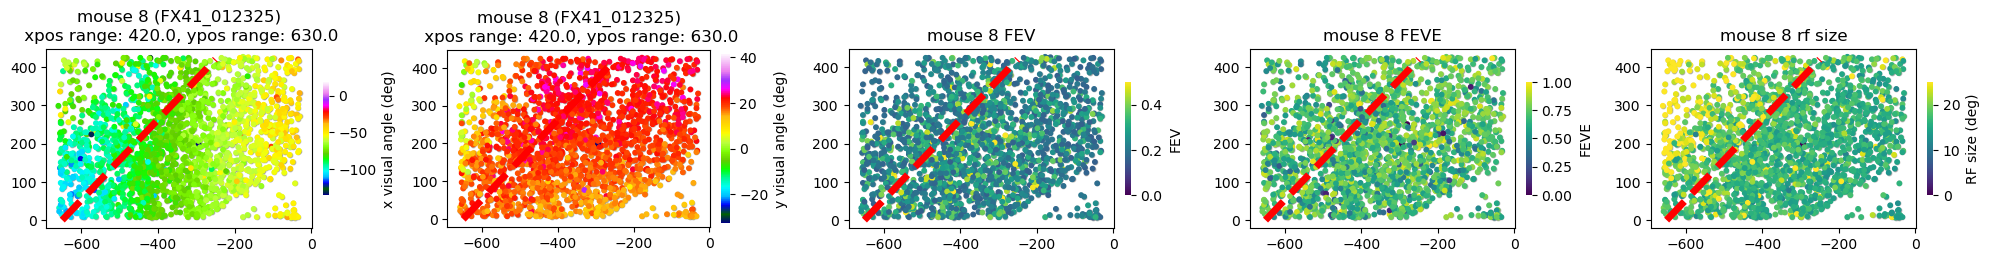

In [15]:
# xpos_visual = xmax*2*(270/264) - 135 # 0 is at the center, so it should be 135 pixels
# ypos_visual = ymax*2*(65/66) - 32.5 # vertical visual range is 65, so it sould be (66/65) pixels per degree
# xpos_plot, ypos_plot  = xpos/pix_res[0], ypos/pix_res[1]
valid_idxes = np.where(test_fev > 0.15)[0]
vmin_x = -135
vmax_x = 270 * (hmax_angle/88)-135
vmin_y = -32.5
vmax_y = 65*(25/22)-32.5
plot_boundary = True
fig, ax = plt.subplots(1, 5, figsize=(20, 3))
ax[0].scatter(-ypos_plot, xpos_plot, s=10, c='gray', alpha=0.5)
sc = ax[0].scatter(-ypos_plot, xpos_plot, c=xpos_visual, s=10, cmap='gist_ncar', vmin=vmin_x, vmax=vmax_x, rasterized=True)
cbar = fig.colorbar(sc, ax=ax[0], fraction=0.02, pad=0.04)
cbar.outline.set_visible(False)
cbar.set_label('x visual angle (deg)')
ax[0].set_title(f'mouse {mouse_id+1} ({data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]})\n xpos range: {np.max(xpos_plot)-np.min(xpos_plot)}, ypos range: {np.max(ypos_plot)-np.min(ypos_plot)}', loc='center')
ax[0].set_aspect('equal', adjustable='box')

# ax.set_axis_off()
# fig.savefig(f'./outputs/{data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]}_xpos_visual.png', dpi=300, bbox_inches='tight')
# plt.close(fig)
ax[1].scatter(-ypos_plot, xpos_plot, s=10, c='gray', alpha=0.5)
sc = ax[1].scatter(-ypos_plot, xpos_plot, c=ypos_visual, s=10, cmap='gist_ncar', vmin=vmin_y, vmax=vmax_y, rasterized=True)
cbar = fig.colorbar(sc, ax=ax[1], fraction=0.03, pad=0.04)
cbar.outline.set_visible(False)
cbar.set_label('y visual angle (deg)')   
ax[1].set_title(f'mouse {mouse_id+1} ({data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]})\n xpos range: {np.max(xpos_plot)-np.min(xpos_plot)}, ypos range: {np.max(ypos_plot)-np.min(ypos_plot)}', loc='center')
ax[1].set_aspect('equal', adjustable='box')
# ax[1].plot([point1[0], point2[0]], [point1[1], point2[1]], 'r--', linewidth=5)

ax[2].scatter(-ypos_plot, xpos_plot, s=10, c='gray', alpha=0.5)
sc = ax[2].scatter(-ypos_plot[valid_idxes], xpos_plot[valid_idxes], c=test_fev[valid_idxes], s=10, cmap='viridis', vmin=0, vmax=0.5)
cbar = fig.colorbar(sc, ax=ax[2], fraction=0.02, pad=0.04)
cbar.outline.set_visible(False)
cbar.set_label('FEV')
ax[2].set_title(f'mouse {mouse_id+1} FEV', loc='center')
ax[2].set_aspect('equal', adjustable='box')
# ax[2].plot([point1[0], point2[0]], [point1[1], point2[1]], 'r--', linewidth=5)

ax[3].scatter(-ypos_plot, xpos_plot, s=10, c='gray', alpha=0.5)
sc = ax[3].scatter(-ypos_plot[valid_idxes], xpos_plot[valid_idxes], c=test_feve[valid_idxes], s=10, cmap='viridis', vmin=0, vmax=1)
cbar = fig.colorbar(sc, ax=ax[3], fraction=0.02, pad=0.04)
cbar.outline.set_visible(False)
cbar.set_label('FEVE')
ax[3].set_title(f'mouse {mouse_id+1} FEVE', loc='center')
ax[3].set_aspect('equal', adjustable='box')

ax[4].scatter(-ypos_plot, xpos_plot, s=10, c='gray', alpha=0.5)
sc = ax[4].scatter(-ypos_plot[valid_idxes], xpos_plot[valid_idxes], c=rf_size[valid_idxes], s=10, cmap='viridis', vmin=0, vmax=25)
cbar = fig.colorbar(sc, ax=ax[4], fraction=0.02, pad=0.04)
cbar.outline.set_visible(False)
cbar.set_label('RF size (deg)')
ax[4].set_title(f'mouse {mouse_id+1} rf size', loc='center')
ax[4].set_aspect('equal', adjustable='box')


if plot_boundary:
    for i in range(5):
        ax[i].plot([point1[0], point2[0]], [point1[1], point2[1]], 'r--', linewidth=5)
# ax[3].plot([point1[0], point2[0]], [point1[1], point2[1]], 'r--', linewidth=5)
plt.tight_layout()


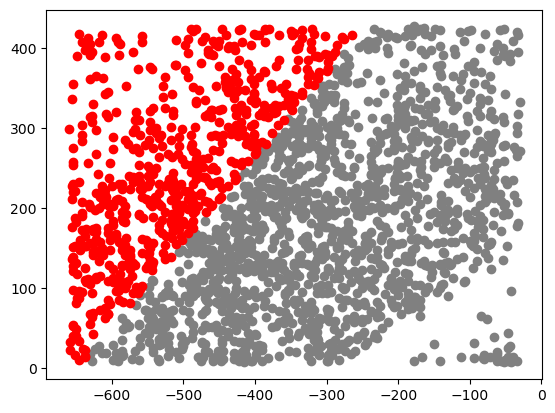

In [16]:
plt.scatter(-ypos_plot[iv1], xpos_plot[iv1], c='gray')
plt.scatter(-ypos_plot[imedial], xpos_plot[imedial], c='red')

p-value for FEV: 0.0000


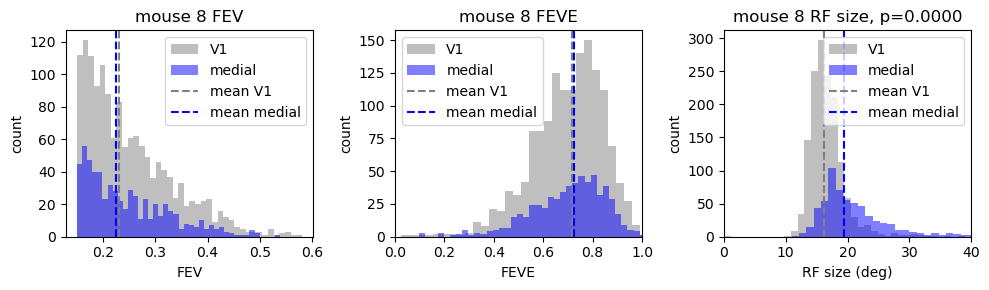

In [17]:
# distribution of FEV and FEVE in medial and V1
fig, ax = plt.subplots(1, 3, figsize=(10, 3))
# iv1 = np.intersect1d(iv1, ivalid)
# imedial = np.intersect1d(imedial, ivalid)
ax[0].hist(test_fev[iv1], bins=40, alpha=0.5, label='V1', color='gray')
ax[0].hist(test_fev[imedial], bins=40, alpha=0.5, label='medial', color='blue')
# plot the mean and std
ax[0].axvline(np.median(test_fev[iv1]), color='gray', linestyle='--', label='mean V1')
ax[0].axvline(np.median(test_fev[imedial]), color='blue', linestyle='--', label='mean medial')
ax[0].set_xlabel('FEV')
ax[0].set_ylabel('count')
ax[0].set_title(f'mouse {mouse_id+1} FEV')
ax[0].legend()
ax[1].hist(test_feve[iv1], bins=40, alpha=0.5, label='V1', color='gray')
ax[1].hist(test_feve[imedial], bins=40, alpha=0.5, label='medial', color='blue')
# plot the mean and std
ax[1].axvline(np.median(test_feve[iv1]), color='gray', linestyle='--', label='mean V1')
ax[1].axvline(np.median(test_feve[imedial]), color='blue', linestyle='--', label='mean medial')
ax[1].set_xlabel('FEVE')
ax[1].set_ylabel('count')
ax[1].set_title(f'mouse {mouse_id+1} FEVE')
ax[1].legend()
ax[1].set_xlim([0,1])

ax[2].hist(rf_size[iv1], bins=40, alpha=0.5, label='V1', color='gray')
ax[2].hist(rf_size[imedial], bins=40, alpha=0.5, label='medial', color='blue')
# plot the mean and std
ax[2].axvline(np.median(rf_size[iv1]), color='gray', linestyle='--', label='mean V1')
ax[2].axvline(np.median(rf_size[imedial]), color='blue', linestyle='--', label='mean medial')
ax[2].set_xlabel('RF size (deg)')
ax[2].set_ylabel('count')

ax[2].legend()
ax[2].set_xlim([0, 40])
# add significance test on the mean
from scipy import stats
t_stat, p_value = stats.ttest_ind(rf_size[iv1], rf_size[imedial])
print(f'p-value for FEV: {p_value:.4f}')
# ax[2].text(0.05, 0.95, f'p-value: {p_value:.4f}', transform=ax[2].transAxes, fontsize=12, verticalalignment='top')
ax[2].set_title(f'mouse {mouse_id+1} RF size, p={p_value:.4f}')
plt.tight_layout()

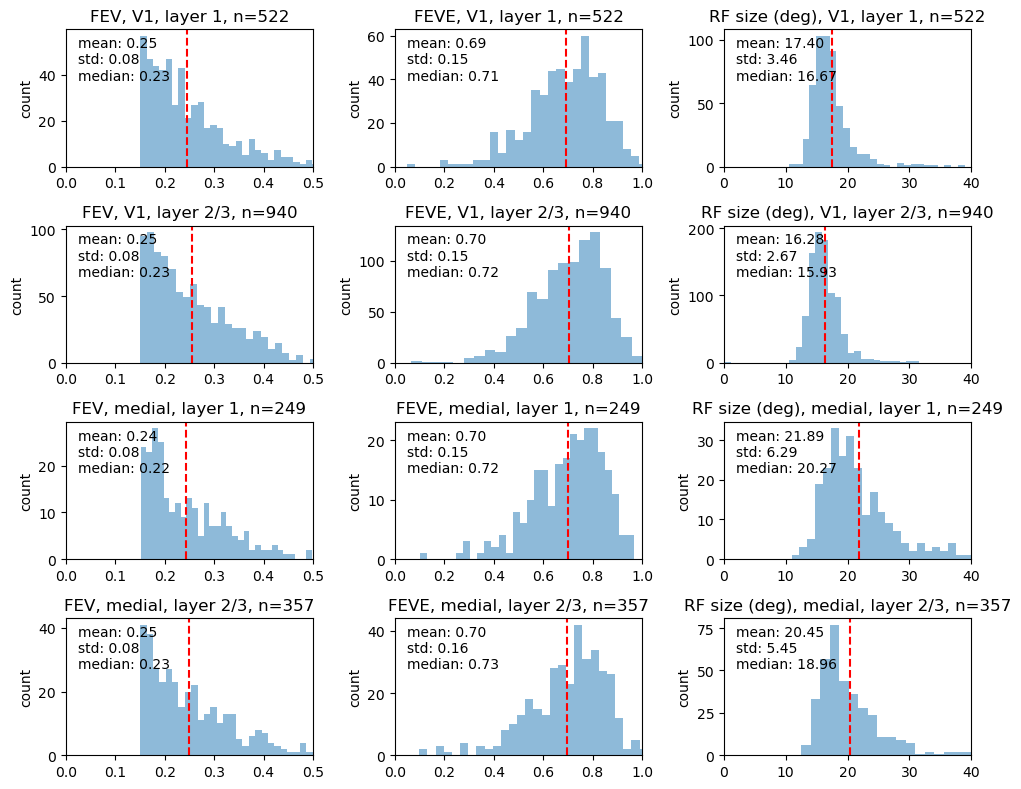

In [18]:
fig, ax = plt.subplots(4, 3, figsize=(10,8))
vars = [test_fev, test_feve, rf_size]
var_names = ['FEV', 'FEVE', 'RF size (deg)']
for i in range(3):
    var_plot = vars[i]
    var_name = var_names[i]
    for iarea in range(2):
        # if iarea == 0:
        #     idxes = iv1
        #     area_name = 'V1'
        # else:
        #     idxes = imedial
        #     area_name = 'medial'
        area_name = 'V1' if iarea==0 else 'medial'
        for ilayer in range(2):
            # indexes = idxes[res_dict['ilayer'][idxes]==(ilayer+1)]
            indexes = np.where((res_dict['iarea']==iarea) & (res_dict['ilayer']==(ilayer+1)))[0]
            layer_name = 'layer 1' if ilayer==0 else 'layer 2/3'
            ax[ilayer+iarea*2, i].hist(var_plot[indexes], bins=30, alpha=0.5)
            ax[ilayer+iarea*2, i].set_title(f'{var_name}, {area_name}, {layer_name}, n={len(indexes)}')
            mu = np.mean(var_plot[indexes])
            sd = np.std(var_plot[indexes])
            med = np.median(var_plot[indexes])
            ax[ilayer+iarea*2, i].axvline(mu, color='red', linestyle='--', label='mean')
            # ax[i, ilayer+iarea*2].axvline(mu+sd, color='orange', linestyle='--', label='std')
            ax[ilayer+iarea*2, i].text(0.05, 0.95, f'mean: {mu:.2f}\nstd: {sd:.2f}\nmedian: {med:.2f}', transform=ax[ilayer+iarea*2, i].transAxes, fontsize=10, verticalalignment='top')
            if i==0: ax[ilayer+iarea*2, i].set_xlim([0, 0.5])
            if i==1: ax[ilayer+iarea*2, i].set_xlim([0, 1])
            if i==2: ax[ilayer+iarea*2, i].set_xlim([0, 40])
            ax[ilayer+iarea*2, i].set_ylabel('count')
plt.tight_layout()

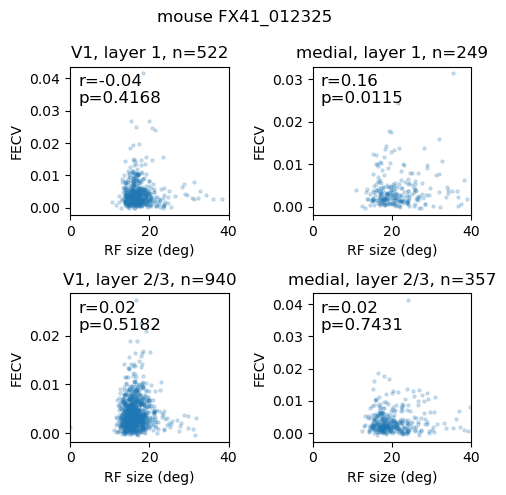

In [19]:
# rfsize vs fecv for different layers and areas
fig, ax = plt.subplots(2, 2, figsize=(5,5))
fecv = res_dict['FECV']
rfsize = res_dict['rf_size_visual']
iareas = res_dict['iarea']
ilayers = res_dict['ilayer']
area_names = ['V1', 'medial']
layer_names = ['layer 1', 'layer 2/3']
for iarea in range(2):
    for ilayer in range(2):
        ax_ = ax[ilayer, iarea]
        idxes = np.where((iareas==iarea) & (ilayers==(ilayer+1)))[0]
        ax_.scatter(rfsize[idxes], fecv[idxes], s=5, alpha=0.2)
        ax_.set_title(f'{area_names[iarea]}, {layer_names[ilayer]}, n={len(idxes)}')
        # statistics
        from scipy import stats
        r, p = stats.pearsonr(rfsize[idxes], fecv[idxes])
        ax_.text(0.05, 0.95, f'r={r:.2f}\np={p:.4f}', transform=ax_.transAxes, fontsize=12, verticalalignment='top')
        ax_.set_xlabel('RF size (deg)')
        ax_.set_ylabel('FECV')
        ax_.set_xlim([0, 40])
plt.suptitle(f'mouse {data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]}')
plt.tight_layout()

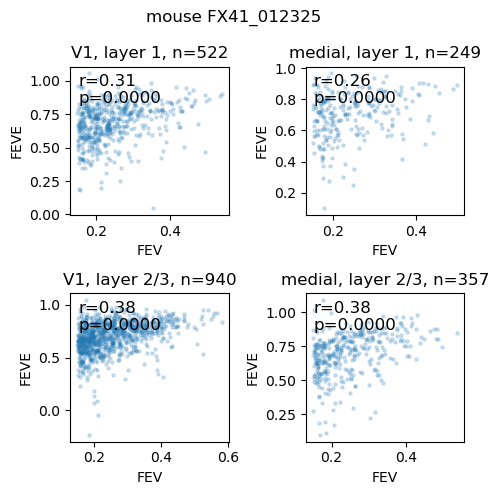

In [20]:
# rfsize vs fecv for different layers and areas
fig, ax = plt.subplots(2, 2, figsize=(5,5))
feve = res_dict['FEVE_fullmodel']
fev = res_dict['FEV']
iareas = res_dict['iarea']
ilayers = res_dict['ilayer']
area_names = ['V1', 'medial']
layer_names = ['layer 1', 'layer 2/3']
for iarea in range(2):
    for ilayer in range(2):
        ax_ = ax[ilayer, iarea]
        idxes = np.where((iareas==iarea) & (ilayers==(ilayer+1)))[0]
        ax_.scatter(fev[idxes], feve[idxes], s=5, alpha=0.2)
        ax_.set_title(f'{area_names[iarea]}, {layer_names[ilayer]}, n={len(idxes)}')
        # statistics
        from scipy import stats
        r, p = stats.pearsonr(fev[idxes], feve[idxes])
        ax_.text(0.05, 0.95, f'r={r:.2f}\np={p:.4f}', transform=ax_.transAxes, fontsize=12, verticalalignment='top')
        ax_.set_xlabel('FEV')
        ax_.set_ylabel('FEVE')
        # ax_.set_xlim([0, 40])
plt.suptitle(f'mouse {data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]}')
plt.tight_layout()

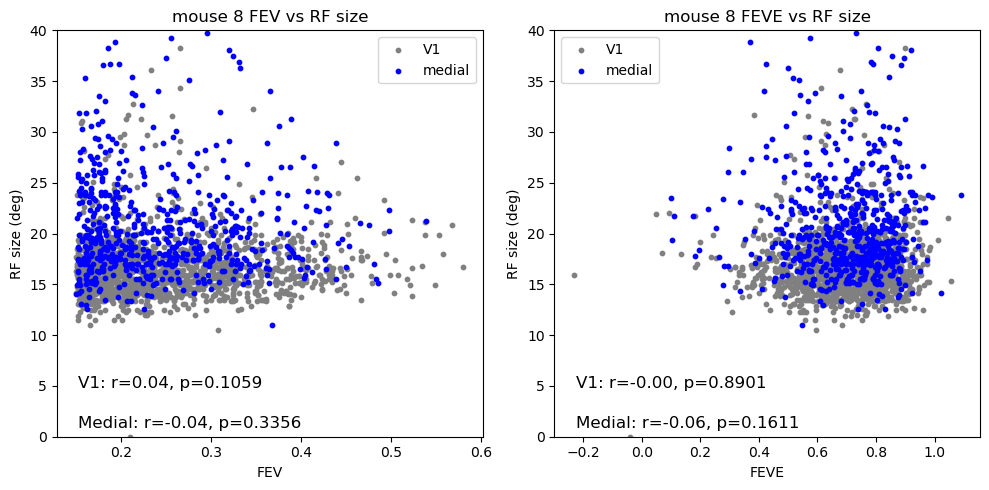

In [21]:
# scatter plot of FEV/FEVE vs RF size on medial and V1 neurons
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].scatter(test_fev[iv1], rf_size[iv1], s=10, c='gray', label='V1')
ax[0].scatter(test_fev[imedial], rf_size[imedial], s=10, c='blue', label='medial')
ax[0].set_xlabel('FEV')
ax[0].set_ylabel('RF size (deg)')
ax[0].set_title(f'mouse {mouse_id+1} FEV vs RF size')
ax[0].set_ylim([0, 40])
# calculate the correlation coefficient and p-value
from scipy import stats
corr_v1, p_v1 = stats.pearsonr(test_fev[iv1], rf_size[iv1])
corr_medial, p_medial = stats.pearsonr(test_fev[imedial], rf_size[imedial])
ax[0].text(0.05, 0.15, f'V1: r={corr_v1:.2f}, p={p_v1:.4f}', transform=ax[0].transAxes, fontsize=12, verticalalignment='top')
ax[0].text(0.05, 0.05, f'Medial: r={corr_medial:.2f}, p={p_medial:.4f}', transform=ax[0].transAxes, fontsize=12, verticalalignment='top')

ax[0].legend()
ax[1].scatter(test_feve[iv1], rf_size[iv1], s=10, c='gray', label='V1')
ax[1].scatter(test_feve[imedial], rf_size[imedial], s=10, c='blue', label='medial')
ax[1].set_xlabel('FEVE')
ax[1].set_ylabel('RF size (deg)')
ax[1].set_title(f'mouse {mouse_id+1} FEVE vs RF size')
ax[1].set_ylim([0, 40])
# calculate the correlation coefficient and p-value
corr_v1, p_v1 = stats.pearsonr(test_feve[iv1], rf_size[iv1])
corr_medial, p_medial = stats.pearsonr(test_feve[imedial], rf_size[imedial])
ax[1].text(0.05, 0.15, f'V1: r={corr_v1:.2f}, p={p_v1:.4f}', transform=ax[1].transAxes, fontsize=12, verticalalignment='top')
ax[1].text(0.05, 0.05, f'Medial: r={corr_medial:.2f}, p={p_medial:.4f}', transform=ax[1].transAxes, fontsize=12, verticalalignment='top')
ax[1].legend()
plt.tight_layout()

In [22]:
# load the models and get FEVE
# 64, 16-64, 16-64-64, 16-64-64-64 model result
from utils import model_builder
nlayers = 2
feve_all = []
nconv2 = 192
for nlayers in [1, 2, 3, 4]:
    if nlayers == 1:
        nconv1 = 192
    else:
        nconv1 = 16
    weight_decay_core = weight_decay_cores[nlayers-1]
    model, in_channels = model_builder.build_model(NN=len(ineur), n_layers=nlayers, n_conv=nconv1, n_conv_mid=nconv2, pool=pool, depth_separable=depth_separable, input_Ly=input_Ly, input_Lx=input_Lx)
    model_name = model_builder.create_model_name(data.mouse_names[mouse_id], data.exp_date[mouse_id], n_layers=nlayers, in_channels=in_channels, clamp=clamp, suffix='', ineuron=len(ineur), crop=crop)
    # weight_path = './checkpoints/'
    model_path = os.path.join(weight_path, 'fullmodel', data.mouse_names[mouse_id], model_name)
    model = model.to(device)

    model.load_state_dict(torch.load(model_path))
    print('loaded model', model_path)

    # test model
    from utils import model_trainer
    test_pred = model_trainer.test_epoch(model, img_test)

    test_fev, test_feve = metrics.feve_nan(spks_rep_all, test_pred)
    print('FEVE (test): ', np.mean(test_feve))

    feve_all.append(test_feve)

input shape of readout:  (192, 33, 65)
model name:  FX41_012325_1layer_192_clamp_sensorium_depthsep_pool_nneurons_2068.pt
loaded model /home/carsen/dm11_cluster/fengtongd/Desktop/github/oneshot/weights/fullmodel/FX41/FX41_012325_1layer_192_clamp_sensorium_depthsep_pool_nneurons_2068.pt
FEVE (test):  0.5681626
input shape of readout:  (192, 33, 65)
model name:  FX41_012325_2layer_16_192_clamp_sensorium_depthsep_pool_nneurons_2068.pt
loaded model /home/carsen/dm11_cluster/fengtongd/Desktop/github/oneshot/weights/fullmodel/FX41/FX41_012325_2layer_16_192_clamp_sensorium_depthsep_pool_nneurons_2068.pt
FEVE (test):  0.69907767
input shape of readout:  (192, 33, 65)
model name:  FX41_012325_3layer_16_192_192_clamp_sensorium_depthsep_pool_nneurons_2068.pt
loaded model /home/carsen/dm11_cluster/fengtongd/Desktop/github/oneshot/weights/fullmodel/FX41/FX41_012325_3layer_16_192_192_clamp_sensorium_depthsep_pool_nneurons_2068.pt
FEVE (test):  0.717119
input shape of readout:  (192, 33, 65)
model na

In [23]:
print(f'FEV(medail): {np.mean(test_fev[imedial]):.2f}, FEV(V1): {np.mean(test_fev[iv1]):.2f}')

FEV(medail): 0.25, FEV(V1): 0.25


FEV(medail): 0.25, FEV(V1): 0.25


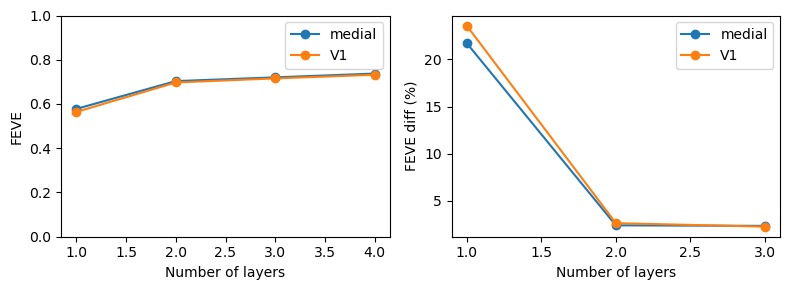

In [24]:
# plot the FEVE change with the number of layers (separate medial and V1)
fig, ax = plt.subplots(1, 2, figsize=(8, 3))
# ivalid = np.where(test_fev > 0.1)[0]
feve_all = np.array(feve_all)
print(f'FEV(medail): {np.mean(test_fev[imedial]):.2f}, FEV(V1): {np.mean(test_fev[iv1]):.2f}')

res_dict['FEVE_all_depth'] = feve_all

feve_medial = np.mean(feve_all[:, imedial], axis=1)
feve_v1 = np.mean(feve_all[:, iv1], axis=1)

ax[0].plot([1, 2, 3, 4], feve_medial, label='medial', marker='o')
ax[0].plot([1, 2, 3, 4], feve_v1, label='V1', marker='o')
# ax[0].plot([1, 2, 3, 4], feve_low_v1, label='V1 (FEVE<0.17)', marker='o')
ax[0].set_xlabel('Number of layers')
ax[0].set_ylabel('FEVE')
ax[0].set_ylim([0,1])
ax[0].legend()

# plot the diff of FEVE between each neighboring layers
feve_diff = np.diff(feve_all, axis=0)
feve_diff_medial = np.mean(feve_diff[:, imedial], axis=1) / feve_medial[:-1] * 100
feve_diff_v1 = np.mean(feve_diff[:, iv1], axis=1) / feve_v1[:-1] * 100

ax[1].plot([1, 2, 3], feve_diff_medial, label='medial', marker='o')
ax[1].plot([1, 2, 3], feve_diff_v1, label='V1', marker='o')
ax[1].set_xlabel('Number of layers')
ax[1].set_ylabel('FEVE diff (%)')
ax[1].legend()
plt.tight_layout()

# pretrained model

In [25]:
# nlayers = 2
# nconv1 = 16
# nconv2 = 320
# pretrain = True
# model, in_channels = model_builder.build_model(NN=len(ineur), n_layers=nlayers, n_conv=nconv1, n_conv_mid=nconv2, pool=pool, depth_separable=depth_separable, input_Ly=input_Ly, input_Lx=input_Lx)
# model_name = model_builder.create_model_name(data.mouse_names[mouse_id], data.exp_date[mouse_id], n_layers=nlayers, in_channels=in_channels, clamp=clamp, suffix='', ineuron=len(ineur), crop=crop, pretrain=pretrain)
# # weight_path = './checkpoints/'
# model_path = os.path.join(weight_path, 'fullmodel', data.mouse_names[mouse_id], model_name)
# model = model.to(device)

# model.load_state_dict(torch.load(model_path))
# print('loaded model', model_path)

# # test model
# from utils import model_trainer
# test_pred = model_trainer.test_epoch(model, img_test)

# test_fev, test_feve = metrics.feve_nan(spks_rep_all, test_pred)
# ivalid = np.where(test_fev > 0.15)[0]
# print(len(ivalid), ' neurons with FEV > 0.15')
# print('FEVE (test): ', np.mean(test_feve[ivalid]))

# res_dict['FEVE_fullmodel_pretrain'] = test_feve

# fullmodel_feve = res_dict['FEVE_fullmodel']
# plt.scatter(fullmodel_feve[iv1], test_feve[iv1], s=5, c='gray', alpha=0.5, label='V1')
# plt.scatter(fullmodel_feve[imedial], test_feve[imedial], s=5, c='blue', alpha=0.5, label='medial')

# gabor model

In [26]:
img_all = data.load_images(data_path, file=os.path.join(data_path, data.img_file_name[mouse_id]), downsample=2, crop=False)
nimg, Ly, Lx = img_all.shape
print('img: ', img_all.shape, img_all.min(), img_all.max())

n_stim = -1 # spks.shape[0]
n_neurons = -1

# generate random data
if n_stim > 0:
    istims = np.random.choice(spks.shape[0], n_stim, replace=False)
else:
    n_stim = spks.shape[0]
    istims = np.arange(n_stim)
if n_neurons > 0:
    ineurons = np.random.choice(spks.shape[1], n_neurons, replace=False)
    X_test = [spks_rep_all[i][:,ineurons] for i in range(len(spks_rep_all))]
else:
    n_neurons = spks.shape[1]
    ineurons = np.arange(n_neurons)
    X_test = spks_rep_all.copy()
X = spks[istims][:,ineurons]
img = img_all[istim_train][istims].transpose(1,2,0)
img_test = img_all[istim_test].transpose(1,2,0)
print(f'img: {img.shape}, X: {X.shape}')
Ly, Lx, _ = img.shape


raw image shape:  (68032, 66, 264)
image mean:  126.714066
image std:  57.67655
img:  (68032, 33, 132) -2.1969771 2.2242303
img: (33, 132, 18709), X: (18709, 5373)


In [27]:
save_path = os.path.join(weight_path, 'gabor', f'gabor_params_{data.db[mouse_id]["mname"]}_{data.db[mouse_id]["datexp"]}_more_f_sigma.npz')
print('load gabor params from', save_path)
result_dict = np.load(save_path, allow_pickle=True)

# define gabor parameters
# sigma = np.array([0.75, 1.25, 1.5, 2.5, 3.5, 4.5, 5.5]) # [2,3,4,5,6,7]
# f = np.array([0.05, 0.1, 0.15, 0.2, 0.25, 0.5, 1, 2]) #[.01:.02:.13];
sigma = np.arange(1, 10, 1)
# np.array([0.75, 1.25, 1.5, 2.5, 3.5, 4.5, 5.5])
f = np.arange(0.1, 1, 0.1)
# np.array([0.05, 0.1, 0.15, 0.2, 0.25, 0.5, 1, 2]) #[.01:.02:.13];
theta = np.arange(0, np.pi, np.pi/8)
ph = np.arange(0, 2*np.pi, np.pi/4)
ar = np.array([1, 1.5, 2])
print(f'sigma: {sigma.shape}, f: {f.shape}, theta: {theta.shape}, ph: {ph.shape}, ar: {ar.shape}')

params = np.meshgrid(sigma, f, theta, ph, ar, indexing='ij')
n_gabors = params[0].size
print(f'number of gabors: {n_gabors}')

for i in range(len(params)):
    params[i] = np.expand_dims(params[i], axis=(-2,-1))
    params[i] = torch.from_numpy(params[i].astype('float32'))
sigma, f, theta, ph, ar = params
print(f'sigma: {sigma.shape}, f: {f.shape}, theta: {theta.shape}, ph: {ph.shape}, ar: {ar.shape}')

xmax, ymax = result_dict['xmax'], result_dict['ymax']
ys, xs = np.meshgrid(np.arange(0,Ly), np.arange(0,Lx), indexing='ij')
ys, xs = torch.from_numpy(ys.astype('float32')), torch.from_numpy(xs.astype('float32'))
gmax = result_dict['gmax']
gabor_params = torch.zeros((5, n_neurons, 1, 1))
for i in range(len(gabor_params)):
    gabor_params[i] = params[i].flatten()[gmax].reshape(n_neurons, 1, 1)
msigma, mf, mtheta, mph, mar = gabor_params
Amax = result_dict['Amax']
mu1 = torch.from_numpy(result_dict['mu1']).to(device)
mu2 = torch.from_numpy(result_dict['mu2']).to(device)
#  test
ym = torch.from_numpy(ymax.astype('float32')).unsqueeze(-1).unsqueeze(-1)
xm = torch.from_numpy(xmax.astype('float32')).unsqueeze(-1).unsqueeze(-1)
# print(f'ym: {ym.shape}, xm: {xm.shape}')
gabor_params = torch.zeros((5, n_neurons, 1, 1))
for i in range(len(gabor_params)):
    gabor_params[i] = params[i].flatten()[gmax].reshape(n_neurons, 1, 1)
msigma, mf, mtheta, mph, mar = gabor_params
from utils.gabor import gabor_filter, eval_gabors
gabor_filters1 = gabor_filter(ys, xs, ym, xm, 1, msigma, mf, mtheta, mph, mar, is_torch=True).to(device).unsqueeze(-3)
gabor_filters2 = gabor_filter(ys, xs, ym, xm, 1, msigma, mf, mtheta, mph + np.pi/2, mar, is_torch=True).to(device).unsqueeze(-3)

# load test images
# img_test = img_all[istim_test].transpose(1,2,0)
# img_test = (img_test - img_mean) / img_std
# print(f'img_test: {img_test.shape} {img_test.min()}, {img_test.max()}')

# predict responses
ntest = len(istim_test)
resp_test1 = torch.zeros((n_neurons, ntest), dtype=torch.float32, device=device)
resp_test2 = torch.zeros((n_neurons, ntest), dtype=torch.float32, device=device)
eval_gabors(img_test, gabor_filters1, resp_test1, device=device, rectify=False)
eval_gabors(img_test, gabor_filters2, resp_test2, device=device, rectify=False)
resp_test2 = torch.sqrt(resp_test1**2 + resp_test2**2) # RMS for complex cell response
from torch.nn.functional import relu
resp_test2 = relu(resp_test2) # rectify
resp_test1 = relu(resp_test1) # rectify

c = torch.from_numpy(Amax).to(device)

rpred = ((resp_test1.T - mu1) * c[:,0] + (resp_test2.T - mu2) * c[:,1]) # (n_stim, n_neurons)
rpred = rpred.cpu().detach().numpy()
print(f'rpred: {rpred.shape}')

load gabor params from /home/carsen/dm11_cluster/fengtongd/Desktop/github/oneshot/weights/gabor/gabor_params_FX41_2025_01_23_more_f_sigma.npz
sigma: (9,), f: (9,), theta: (8,), ph: (8,), ar: (3,)
number of gabors: 15552
sigma: torch.Size([9, 9, 8, 8, 3, 1, 1]), f: torch.Size([9, 9, 8, 8, 3, 1, 1]), theta: torch.Size([9, 9, 8, 8, 3, 1, 1]), ph: torch.Size([9, 9, 8, 8, 3, 1, 1]), ar: torch.Size([9, 9, 8, 8, 3, 1, 1])
rpred: (500, 5373)


In [28]:
# # test responses
train_mu = result_dict['train_mu'][ineur]
train_std = result_dict['train_std'][ineur]
# rpred = result_dict['rpred']
spks_rep_all = X_test.copy()
nreps = []
for i in range(len(spks_rep_all)):
    spks_rep_all[i] -= train_mu
    spks_rep_all[i] /= train_std
    nreps.append(spks_rep_all[i].shape[0])

In [29]:
fev, feve = metrics.feve(spks_rep_all, rpred[:, ineur], nreps)
print(f'fev:{fev.mean():.3f}, feve:{feve.mean():.3f}')

cratio = Amax[:,1]/Amax.sum(axis=1)

res_dict['gabor_feve'] = feve
res_dict['gabor_mf'] = mf.cpu().detach().numpy().squeeze()[ineur]
res_dict['gabor_msigma'] = msigma.cpu().detach().numpy().squeeze()[ineur]
res_dict['gabor_mtheta'] = mtheta.cpu().detach().numpy().squeeze()[ineur]
# res_dict['iplane'] = iplane[ineur]

fev:0.250, feve:0.327


# save

In [30]:
save_path = './result'
if not os.path.exists(save_path):
    os.makedirs(save_path)
save_name = f'{data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]}_fullmodel_result.npz'
np.savez(os.path.join(save_path, save_name), **res_dict)

In [31]:
# display all names
print('All names in res_dict:')
for key in res_dict:
    print(key, ':', res_dict[key].shape if isinstance(res_dict[key], np.ndarray) else type(res_dict[key]))

All names in res_dict:
mouse_id : <class 'int'>
ineur : (2068,)
iarea : (2068,)
ilayer : (2068,)
xpos : (2068,)
ypos : (2068,)
FEV_all : (5373,)
FEV : (2068,)
speed : (255885,)
conv1_w : (16, 25, 25)
FEVE_fullmodel : (2068,)
FECV : (2068,)
FECV_model : (2068,)
xpos_model : (2068,)
ypos_model : (2068,)
xpos_visual : (2068,)
ypos_visual : (2068,)
xpos_plot : (2068,)
ypos_plot : (2068,)
rf_size_visual : (2068,)
FEVE_all_depth : (4, 2068)
gabor_feve : (2068,)
gabor_mf : (2068,)
gabor_msigma : (2068,)
gabor_mtheta : (2068,)


In [32]:
d

NameError: name 'd' is not defined

# PLOT

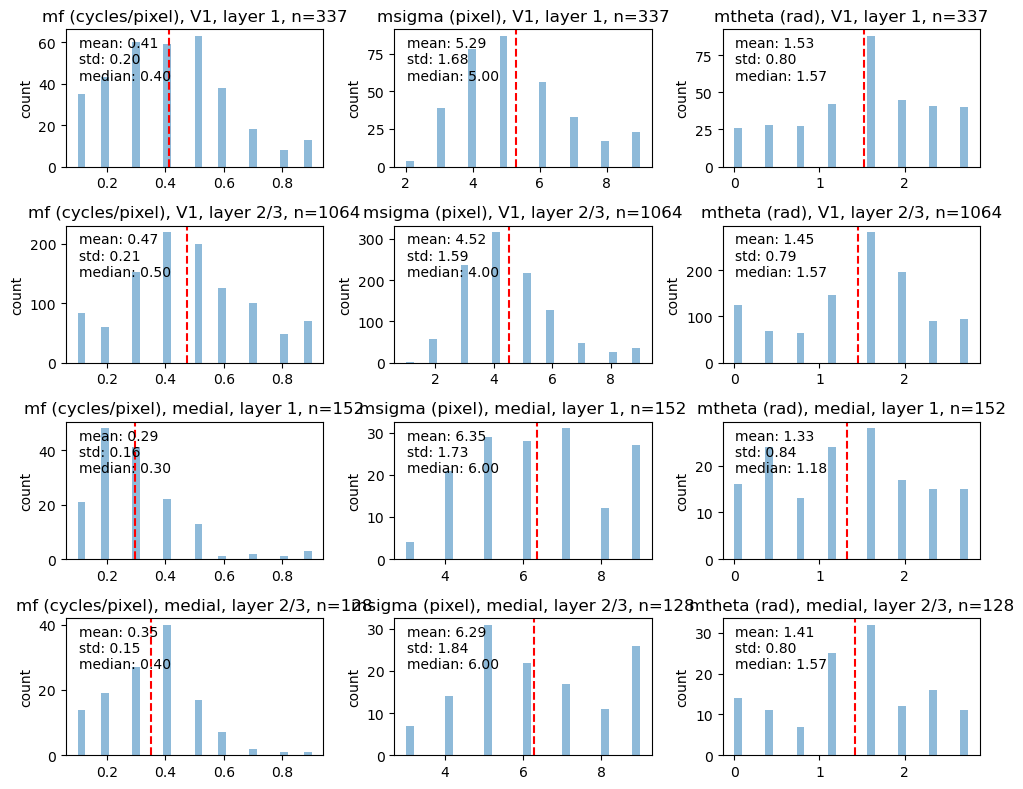

In [ ]:
fig, ax = plt.subplots(4, 3, figsize=(10,8))
gabor_mf = res_dict['gabor_mf']
gabor_msigma = res_dict['gabor_msigma']
gabor_mtheta = res_dict['gabor_mtheta']
vars = [gabor_mf, gabor_msigma, gabor_mtheta]
ilayers = res_dict['ilayer']
iareas = res_dict['iarea']
var_names = ['mf (cycles/pixel)', 'msigma (pixel)', 'mtheta (rad)']
for i in range(3):
    var_plot = vars[i]
    var_name = var_names[i]
    for iarea in range(2):
        area_name = 'V1' if iarea==0 else 'medial'
        for ilayer in range(2):
            indexes = np.where((res_dict['iarea']==iarea) & (res_dict['ilayer']==(ilayer+1)))[0]
            layer_name = 'layer 1' if ilayer==0 else 'layer 2/3'
            ax[ilayer+iarea*2, i].hist(var_plot[indexes], bins=30, alpha=0.5)
            ax[ilayer+iarea*2, i].set_title(f'{var_name}, {area_name}, {layer_name}, n={len(indexes)}')
            mu = np.mean(var_plot[indexes])
            sd = np.std(var_plot[indexes])
            med = np.median(var_plot[indexes])
            ax[ilayer+iarea*2, i].axvline(mu, color='red', linestyle='--', label='mean')
            # ax[i, ilayer+iarea*2].axvline(mu+sd, color='orange', linestyle='--', label='std')
            ax[ilayer+iarea*2, i].text(0.05, 0.95, f'mean: {mu:.2f}\nstd: {sd:.2f}\nmedian: {med:.2f}', transform=ax[ilayer+iarea*2, i].transAxes, fontsize=10, verticalalignment='top')
            # if i==0: ax[ilayer+iarea*2, i].set_xlim([0, 0.5])
            # if i==1: ax[ilayer+iarea*2, i].set_xlim([0, 1])
            # if i==2: ax[ilayer+iarea*2, i].set_xlim([0, 40])
            ax[ilayer+iarea*2, i].set_ylabel('count')
plt.tight_layout()

In [ ]:
d

NameError: name 'd' is not defined

# load all

In [ ]:
save_path = './result'
rfsize_all = []
fecv_all = []
model_fecv_all = []
layers_all = []
areas_all = []
feve_all = []
fev_all = []
mf_all = []
msigma_all = []
mtheta_all = []
planes_all = []
all_depth_feve = []
mouse_ids_all = []
area_names = ['V1', 'medial']
layer_names = ['layer 1', 'layer 2/3']
for i, mouse_id in enumerate(mouse_ids):
    res_dict = np.load(os.path.join(save_path, f'{data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]}_fullmodel_result.npz'), allow_pickle=True)
    fev = res_dict['FEV'].astype(float)
    rf_size = res_dict['rf_size_visual'].astype(float)
    feve = res_dict['FEVE_fullmodel'].astype(float)
    fecv = res_dict['FECV'].astype(float)
    model_fecv = res_dict['FECV_model'].astype(float)
    ilayer = res_dict['ilayer'].astype(int)
    iarea = res_dict['iarea'].astype(int)
    gabor_mf = res_dict['gabor_mf'].astype(float)
    gabor_msigma = res_dict['gabor_msigma'].astype(float)
    gabor_mtheta = res_dict['gabor_mtheta'].astype(float)
    depth_feve = res_dict['FEVE_all_depth'].astype(float) # (n_depth, n_neurons)
    all_depth_feve.append(depth_feve)
    rfsize_all.append(rf_size)
    fecv_all.append(fecv)
    model_fecv_all.append(model_fecv)
    feve_all.append(feve)
    fev_all.append(fev)
    layers_all.append(ilayer)
    areas_all.append(iarea)
    mf_all.append(gabor_mf)
    msigma_all.append(gabor_msigma)
    mtheta_all.append(gabor_mtheta)
    mouse_ids_all.append(np.ones_like(fev)*i)
rfsize_all = np.concatenate(rfsize_all)
fecv_all = np.concatenate(fecv_all)
model_fecv_all = np.concatenate(model_fecv_all)
feve_all = np.concatenate(feve_all)
fev_all = np.concatenate(fev_all)
layers_all = np.concatenate(layers_all)
areas_all = np.concatenate(areas_all)
mf_all = np.concatenate(mf_all)
msigma_all = np.concatenate(msigma_all)
mtheta_all = np.concatenate(mtheta_all)
mouse_ids_all = np.concatenate(mouse_ids_all)
all_depth_feve = np.concatenate(all_depth_feve, axis=1) # (n_depth, n_neurons_total)

print(f'rfsize_all: {rfsize_all.shape}, fecv_all: {fecv_all.shape}, feve_all: {feve_all.shape}, fev_all: {fev_all.shape}, layers_all: {layers_all.shape}, areas_all: {areas_all.shape}, mf_all: {mf_all.shape}, msigma_all: {msigma_all.shape}, mtheta_all: {mtheta_all.shape}')

rfsize_all: (6596,), fecv_all: (6596,), feve_all: (6596,), fev_all: (6596,), layers_all: (6596,), areas_all: (6596,), mf_all: (6596,), msigma_all: (6596,), mtheta_all: (6596,)


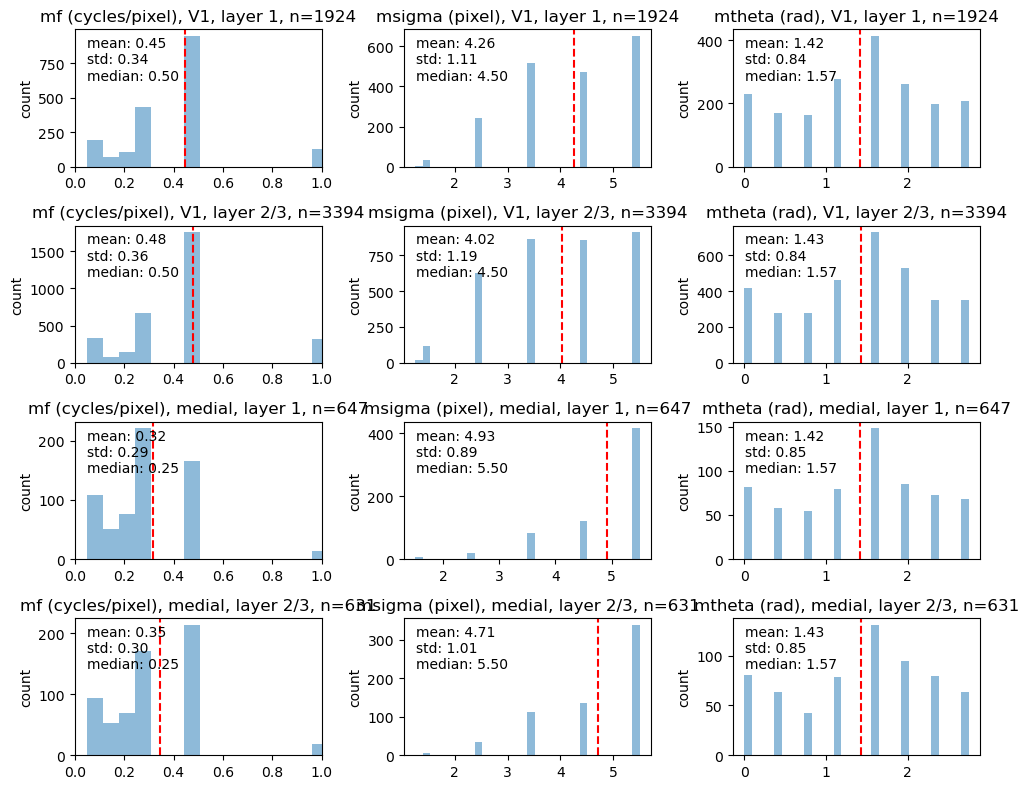

In [ ]:
fig, ax = plt.subplots(4, 3, figsize=(10,8))
gabor_mf = mf_all
gabor_msigma = msigma_all
gabor_mtheta = mtheta_all
vars = [gabor_mf, gabor_msigma, gabor_mtheta]
ilayers = layers_all
iareas = areas_all
var_names = ['mf (cycles/pixel)', 'msigma (pixel)', 'mtheta (rad)']
for i in range(3):
    var_plot = vars[i]
    var_name = var_names[i]
    for iarea in range(2):
        area_name = 'V1' if iarea==0 else 'medial'
        for ilayer in range(2):
            indexes = np.where((iareas == iarea) & (ilayers == (ilayer+1)))[0]
            layer_name = 'layer 1' if ilayer==0 else 'layer 2/3'
            ax[ilayer+iarea*2, i].hist(var_plot[indexes], bins=30, alpha=0.5)
            ax[ilayer+iarea*2, i].set_title(f'{var_name}, {area_name}, {layer_name}, n={len(indexes)}')
            mu = np.mean(var_plot[indexes])
            sd = np.std(var_plot[indexes])
            med = np.median(var_plot[indexes])
            ax[ilayer+iarea*2, i].axvline(mu, color='red', linestyle='--', label='mean')
            # add std band
            # ax[ilayer+iarea*2, i].axvspan(mu-sd, mu+sd, color='orange', alpha=0.3, label='std')
            # ax[i, ilayer+iarea*2].axvline(mu+sd, color='orange', linestyle='--', label='std')
            ax[ilayer+iarea*2, i].text(0.05, 0.95, f'mean: {mu:.2f}\nstd: {sd:.2f}\nmedian: {med:.2f}', transform=ax[ilayer+iarea*2, i].transAxes, fontsize=10, verticalalignment='top')
            if i==0: ax[ilayer+iarea*2, i].set_xlim([0, 1])
            # if i==1: ax[ilayer+iarea*2, i].set_xlim([0, 1])
            # if i==2: ax[ilayer+iarea*2, i].set_xlim([0, 40])
            ax[ilayer+iarea*2, i].set_ylabel('count')
plt.tight_layout()

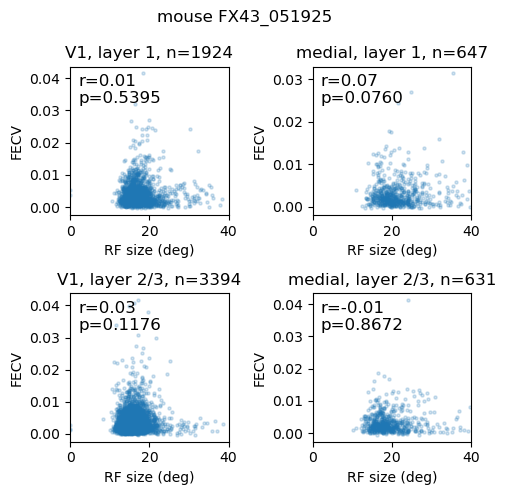

In [ ]:
# rfsize vs fecv for different layers and areas
fig, ax = plt.subplots(2, 2, figsize=(5,5))
fecv = fecv_all
rfsize = rfsize_all
iareas = areas_all
ilayers = layers_all
for iarea in range(2):
    for ilayer in range(2):
        ax_ = ax[ilayer, iarea]
        idxes = np.where((iareas==iarea) & (ilayers==(ilayer+1)))[0]
        ax_.scatter(rfsize[idxes], fecv[idxes], s=5, alpha=0.2)
        ax_.set_title(f'{area_names[iarea]}, {layer_names[ilayer]}, n={len(idxes)}')
        # statistics
        from scipy import stats
        r, p = stats.pearsonr(rfsize[idxes], fecv[idxes])
        ax_.text(0.05, 0.95, f'r={r:.2f}\np={p:.4f}', transform=ax_.transAxes, fontsize=12, verticalalignment='top')
        ax_.set_xlabel('RF size (deg)')
        ax_.set_ylabel('FECV')
        ax_.set_xlim([0, 40])
plt.suptitle(f'mouse {data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]}')
plt.tight_layout()

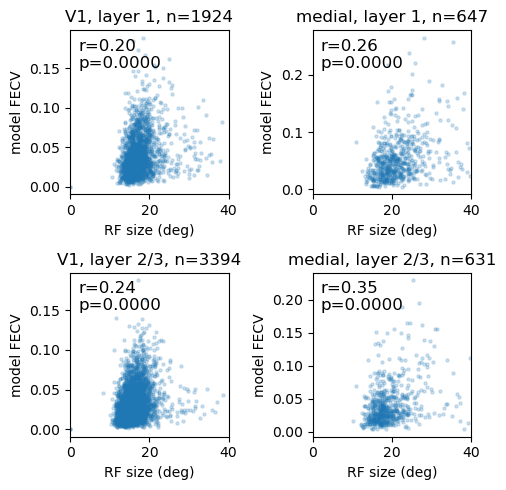

In [ ]:
# rfsize vs fecv for different layers and areas
fig, ax = plt.subplots(2, 2, figsize=(5,5))
fecv = fecv_all
model_fecv = model_fecv_all
model_fecv[np.isnan(model_fecv)] = 0
rfsize = rfsize_all
iareas = areas_all
ilayers = layers_all
for iarea in range(2):
    for ilayer in range(2):
        ax_ = ax[ilayer, iarea]
        idxes = np.where((iareas==iarea) & (ilayers==(ilayer+1)))[0]
        ax_.scatter(rfsize[idxes], model_fecv_all[idxes], s=5, alpha=0.2)
        ax_.set_title(f'{area_names[iarea]}, {layer_names[ilayer]}, n={len(idxes)}')
        # statistics
        from scipy import stats
        r, p = stats.pearsonr(rfsize[idxes], model_fecv_all[idxes])
        ax_.text(0.05, 0.95, f'r={r:.2f}\np={p:.4f}', transform=ax_.transAxes, fontsize=12, verticalalignment='top')
        ax_.set_xlabel('RF size (deg)')
        ax_.set_ylabel('model FECV')
        ax_.set_xlim([0, 40])
plt.tight_layout()

In [ ]:
# rfsize vs fecv for different layers and areas
fig, ax = plt.subplots(2, 2, figsize=(5,5))
fecv = fecv_all
rfsize = rfsize_all
iareas = areas_all
ilayers = layers_all
for iarea in range(2):
    for ilayer in range(2):
        ax_ = ax[ilayer, iarea]
        idxes = np.where((iareas==iarea) & (ilayers==(ilayer+1)))[0]
        ax_.scatter(rfsize[idxes], fecv[idxes], s=5, alpha=0.2)
        ax_.set_title(f'{area_names[iarea]}, {layer_names[ilayer]}, n={len(idxes)}')
        # statistics
        from scipy import stats
        r, p = stats.pearsonr(rfsize[idxes], model_fecv[idxes])
        ax_.text(0.05, 0.95, f'r={r:.2f}\np={p:.4f}', transform=ax_.transAxes, fontsize=12, verticalalignment='top')
        ax_.set_xlabel('RF size (deg)')
        ax_.set_ylabel('FECV')
        ax_.set_xlim([0, 40])
plt.suptitle(f'mouse {data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]}')
plt.tight_layout()

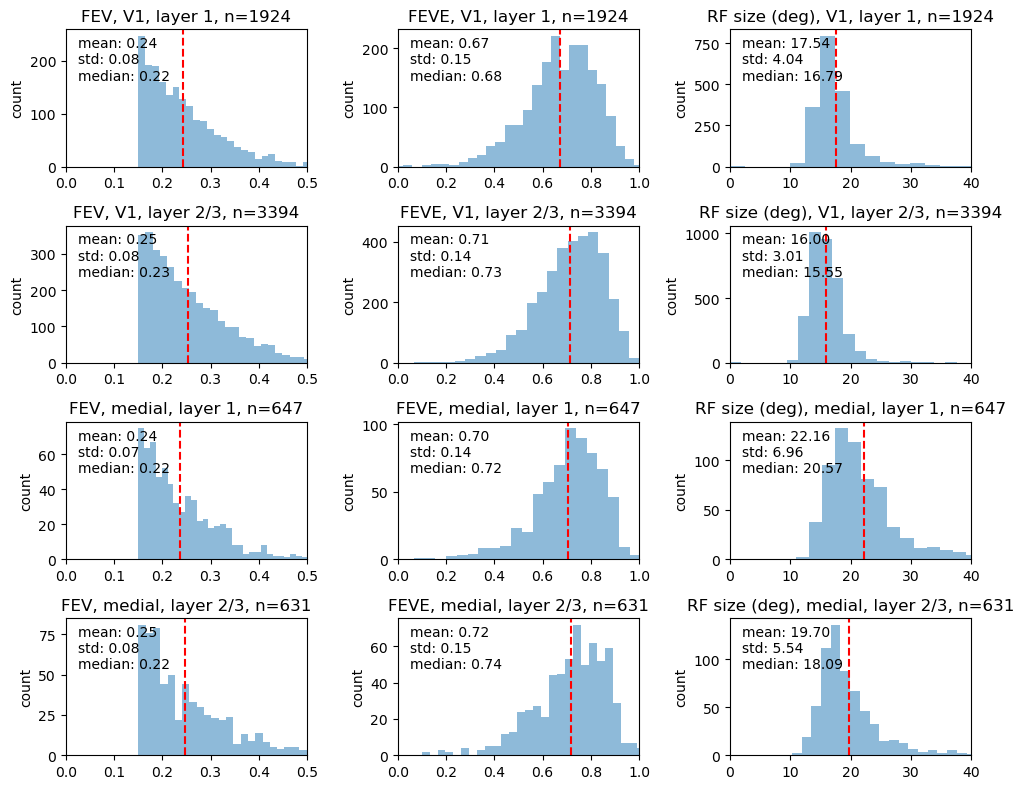

In [ ]:
fig, ax = plt.subplots(4, 3, figsize=(10,8))
vars = [fev_all, feve_all, rfsize_all]
var_names = ['FEV', 'FEVE', 'RF size (deg)']
for i in range(3):
    var_plot = vars[i]
    var_name = var_names[i]
    for iarea in range(2):
        area_name = 'V1' if iarea==0 else 'medial'
        for ilayer in range(2):
            # indexes = idxes[res_dict['ilayer'][idxes]==(ilayer+1)]
            indexes = np.where((areas_all==iarea) & (layers_all==(ilayer+1)))[0]
            layer_name = 'layer 1' if ilayer==0 else 'layer 2/3'
            ax[ilayer+iarea*2, i].hist(var_plot[indexes], bins=30, alpha=0.5)
            ax[ilayer+iarea*2, i].set_title(f'{var_name}, {area_name}, {layer_name}, n={len(indexes)}')
            mu = np.mean(var_plot[indexes])
            sd = np.std(var_plot[indexes])
            med = np.median(var_plot[indexes])
            ax[ilayer+iarea*2, i].axvline(mu, color='red', linestyle='--', label='mean')
            # ax[i, ilayer+iarea*2].axvline(mu+sd, color='orange', linestyle='--', label='std')
            ax[ilayer+iarea*2, i].text(0.05, 0.95, f'mean: {mu:.2f}\nstd: {sd:.2f}\nmedian: {med:.2f}', transform=ax[ilayer+iarea*2, i].transAxes, fontsize=10, verticalalignment='top')
            if i==0: ax[ilayer+iarea*2, i].set_xlim([0, 0.5])
            if i==1: ax[ilayer+iarea*2, i].set_xlim([0, 1])
            if i==2: ax[ilayer+iarea*2, i].set_xlim([0, 40])
            ax[ilayer+iarea*2, i].set_ylabel('count')
plt.tight_layout()

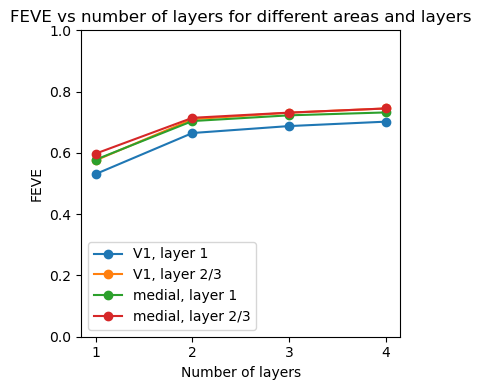

In [ ]:
# plot all depth feve with different areas and layers
fig, ax = plt.subplots(1, 1, figsize=(4,4))
n_depth = all_depth_feve.shape[0]
depths = np.arange(1, n_depth+1)
for iarea in range(2):
    area_name = 'V1' if iarea==0 else 'medial'
    for ilayer in range(2):
        indexes = np.where((areas_all==iarea) & (layers_all==(ilayer+1)))[0]
        layer_name = 'layer 1' if ilayer==0 else 'layer 2/3'
        feve_mean = np.mean(all_depth_feve[:, indexes], axis=1)
        ax.plot(depths, feve_mean, marker='o', label=f'{area_name}, {layer_name}')
ax.set_xlabel('Number of layers')
ax.set_ylabel('FEVE')
ax.set_title('FEVE vs number of layers for different areas and layers')
ax.set_xticks(depths)
ax.set_ylim([0, 1])
ax.legend()
plt.tight_layout()

# V1 vs medial

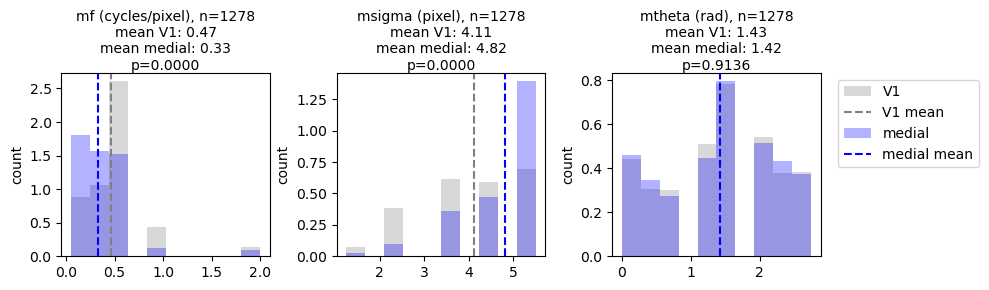

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(10,3))
gabor_mf = mf_all
gabor_msigma = msigma_all
gabor_mtheta = mtheta_all
vars = [gabor_mf, gabor_msigma, gabor_mtheta]
ilayers = layers_all
iareas = areas_all
var_names = ['mf (cycles/pixel)', 'msigma (pixel)', 'mtheta (rad)']
area_colors = ['gray', 'blue']
for i in range(3):
    var_plot = vars[i]
    var_name = var_names[i]
    for iarea in range(2):
        area_name = 'V1' if iarea==0 else 'medial'
        indexes = np.where(iareas == iarea)[0]
        ax[i].hist(var_plot[indexes], bins=10, alpha=0.3, color=area_colors[iarea], label=area_name, density=True)
        mu = np.mean(var_plot[indexes])
        sd = np.std(var_plot[indexes])
        med = np.median(var_plot[indexes])
        ax[i].axvline(mu, color=area_colors[iarea], linestyle='--', label=f'{area_name} mean')
        # if i==0: ax[i].set_xlim([0, 1])
        # if i==1: ax[i].set_xlim([0, 10])
        # if i==2: ax[i].set_xlim([0, 40])
        ax[i].set_ylabel('count')
        # ax[i].legend()
    # stats test between areas
    from scipy import stats
    indexes_v1 = np.where(iareas == 0)[0]
    indexes_medial = np.where(iareas == 1)[0]
    t, p = stats.ttest_ind(var_plot[indexes_v1], var_plot[indexes_medial], equal_var=False)
    ax[i].set_title(f'{var_name}, n={len(indexes)}\nmean V1: {np.mean(var_plot[indexes_v1]):.2f}\nmean medial: {np.mean(var_plot[indexes_medial]):.2f}\np={p:.4f}', transform=ax[i].transAxes, fontsize=10, verticalalignment='top')
# add legend outside after the final subplot
ax[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

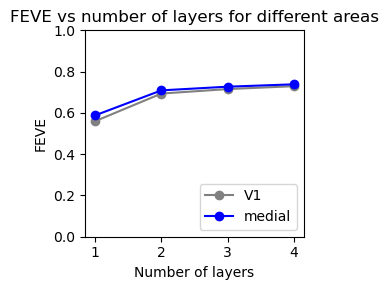

In [ ]:
# plot all depth feve with different areas
fig, ax = plt.subplots(1, 1, figsize=(3,3))
n_depth = all_depth_feve.shape[0]
depths = np.arange(1, n_depth+1)
for iarea in range(2):
    area_name = 'V1' if iarea==0 else 'medial'
    indexes = np.where((areas_all==iarea))[0]
    feve_mean = np.mean(all_depth_feve[:, indexes], axis=1)
    ax.plot(depths, feve_mean, marker='o', label=f'{area_name}', color=area_colors[iarea])

ax.set_xlabel('Number of layers')
ax.set_ylabel('FEVE')
ax.set_title('FEVE vs number of layers for different areas')
ax.set_xticks(depths)
ax.set_ylim([0, 1])
ax.legend(loc='lower right')
plt.tight_layout()

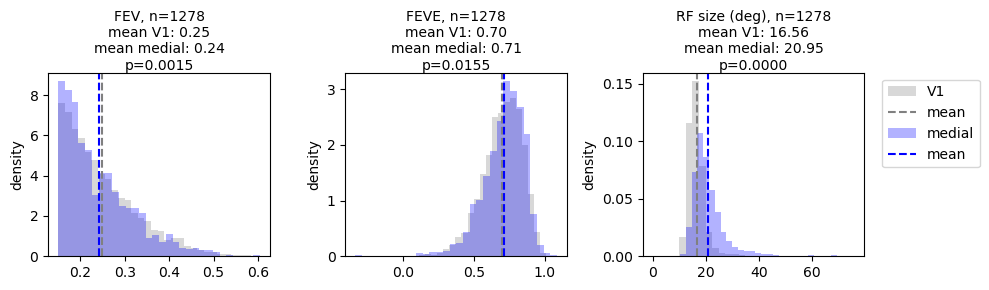

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(10,3))
vars = [fev_all, feve_all, rfsize_all]
var_names = ['FEV', 'FEVE', 'RF size (deg)']
for i in range(3):
    var_plot = vars[i]
    var_name = var_names[i]
    for iarea in range(2):
        area_name = 'V1' if iarea==0 else 'medial'
        indexes = np.where(areas_all==iarea)[0]
        ax[i].hist(var_plot[indexes], bins=30, alpha=0.3, color=area_colors[iarea], label=area_name, density=True)
        ax[i].set_title(f'{var_name}, {area_name}, n={len(indexes)}')
        mu = np.mean(var_plot[indexes])
        sd = np.std(var_plot[indexes])
        med = np.median(var_plot[indexes])
        ax[i].axvline(mu, color=area_colors[iarea], linestyle='--', label='mean')
        ax[i].set_ylabel('density')
    from scipy import stats
    indexes_v1 = np.where(areas_all == 0)[0]
    indexes_medial = np.where(areas_all == 1)[0]
    t, p = stats.ttest_ind(var_plot[indexes_v1], var_plot[indexes_medial], equal_var=False)
    ax[i].set_title(f'{var_name}, n={len(indexes)}\nmean V1: {np.mean(var_plot[indexes_v1]):.2f}\nmean medial: {np.mean(var_plot[indexes_medial]):.2f}\np={p:.4f}', transform=ax[i].transAxes, fontsize=10, verticalalignment='top')
# add legend outside after the final subplot
ax[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

# load all

iplane: (3098,) 0 3
mouse 7, layer 1, iv1_plane: (802,), imedial_plane: (402,)
mouse 7, layer 2, iv1_plane: (1333,), imedial_plane: (561,)
iplane: (2593,) 0 3
mouse 8, layer 1, iv1_plane: (1325,), imedial_plane: (208,)
mouse 8, layer 2, iv1_plane: (944,), imedial_plane: (116,)
iplane: (1340,) 0 3
mouse 10, layer 1, iv1_plane: (301,), imedial_plane: (223,)
mouse 10, layer 2, iv1_plane: (786,), imedial_plane: (30,)
iplane: (476,) 0 1
iplane: (2341,) 0 3
mouse 12, layer 1, iv1_plane: (630,), imedial_plane: (90,)
mouse 12, layer 2, iv1_plane: (1495,), imedial_plane: (126,)


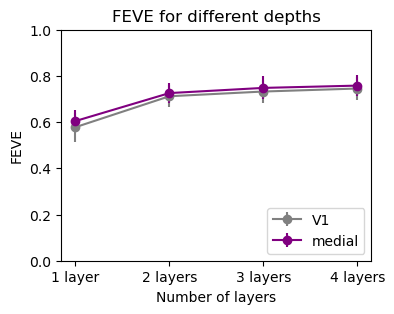

In [ ]:
from scipy import stats
save_path = './result'
mouse_ids = [7,8,10,11,12]
nmouse = len(mouse_ids)
narea = 2
feve_depth_all = np.zeros((narea, nmouse, 4))
ts, ps = np.zeros((nmouse, 4)), np.zeros((nmouse, 4))
fev_all = [[], []]
rfsize_all = [[], []]  # to store RF size for V1 and medial areas
mf_all = [[], []]  # to store mf for V1 and medial areas
mtheta_all = [[], []]  # to store mtheta for V1 and medial areas

# record the mean of all params across plane and area
nplane = 2 # nlayer
feve_depth_all = np.zeros((narea, nmouse-1, nplane, 4))
feve_plane = np.ones((narea, nmouse-1, nplane)) * np.nan
fev_plane = np.ones((narea, nmouse-1, nplane)) * np.nan
rfsize_plane = np.ones((narea, nmouse-1, nplane)) * np.nan  # to store RF size for V1 and medial areas
mf_plane = np.ones((narea, nmouse-1, nplane)) * np.nan  # to store mf for V1 and medial areas
mtheta_plane = np.ones((narea, nmouse-1, nplane)) * np.nan  # to store mtheta for V1 and medial areas
# fev_plane = np.zeros((narea, nmouse-1, nplane))
# rfsize_plane = np.zeros((narea, nmouse-1, nplane))  # to store RF size for V1 and medial areas
# mf_plane = np.zeros((narea, nmouse-1, nplane))  # to store mf for V1 and medial areas
# mtheta_plane = np.zeros((narea, nmouse-1, nplane))  # to store mtheta for V1 and medial areas
for i, mouse_id in enumerate(mouse_ids):
    res_dict = np.load(os.path.join(save_path, f'{data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]}_fullmodel_result.npz'), allow_pickle=True)
    feve_all = res_dict['FEVE_all_depth'].astype(float)
    feve = res_dict['FEVE_fullmodel'].astype(float)
    fev = res_dict['FEV'].astype(float)
    iarea = res_dict['iarea']
    mf = res_dict['gabor_mf'].astype(float).squeeze()
    mtheta = res_dict['gabor_mtheta'].astype(float).squeeze()
    iplanes = res_dict['iplane'].astype(int).squeeze()
    print('iplane:', iplanes.shape, iplanes.min(), iplanes.max())
    layers = np.zeros(iplanes.shape)
    layers[iplanes==0] = 2
    layers[iplanes==1] = 1
    layers[iplanes==2] = 2
    layers[iplanes==3] = 1
    NN = len(fev)
    ivalid = np.where(fev > 0.15)[0]
    iv1 = np.where(iarea == 0)[0]
    imedial = np.where(iarea == 1)[0]
    iv1_valid = np.intersect1d(iv1, ivalid)
    imedial_valid = np.intersect1d(imedial, ivalid)
    # feve_depth_all[i, :] = np.mean(feve_all[:, ivalid], axis=1)
    feve_depth_all[0, i, :] = np.mean(feve_all[:, iv1_valid], axis=1)
    feve_depth_all[1, i, :] = np.mean(feve_all[:, imedial_valid], axis=1)
    fev_all[0].append(fev[iv1_valid])
    fev_all[1].append(fev[imedial_valid])
    rf_size = res_dict['rf_size_visual'].astype(float)
    rfsize_all[0].append(rf_size[iv1_valid])
    rfsize_all[1].append(rf_size[imedial_valid])
    mf_all[0].append(mf[iv1_valid])
    mf_all[1].append(mf[imedial_valid])
    mtheta_all[0].append(mtheta[iv1_valid])
    mtheta_all[1].append(mtheta[imedial_valid])
    # stats test for two distributions
    for ilayer in range(4):
        t_stat, p_value = stats.ttest_ind(feve_all[ilayer, iv1_valid], feve_all[ilayer, imedial_valid], equal_var=False)
        ts[i, ilayer] = t_stat
        ps[i, ilayer] = p_value
    if mouse_id in [7,8,10,12]:
        if mouse_id == 12: i=i-1
        for ilayer in range(2):
            iv1_plane = np.intersect1d(iv1, np.where(layers == ilayer+1)[0])
            imedial_plane = np.intersect1d(imedial, np.where(layers == ilayer+1)[0])
            print(f'mouse {mouse_id}, layer {ilayer+1}, iv1_plane: {iv1_plane.shape}, imedial_plane: {imedial_plane.shape}')
            feve_plane[0, i, ilayer] = np.mean(feve[iv1_plane])
            feve_plane[1, i, ilayer] = np.mean(feve[imedial_plane])
            fev_plane[0, i, ilayer] = np.mean(fev[iv1_plane])
            fev_plane[1, i, ilayer] = np.mean(fev[imedial_plane])
            rfsize_plane[0, i, ilayer] = np.mean(rf_size[iv1_plane])
            rfsize_plane[1, i, ilayer] = np.mean(rf_size[imedial_plane])
            mf_plane[0, i, ilayer] = np.mean(mf[iv1_plane])
            mf_plane[1, i, ilayer] = np.mean(mf[imedial_plane])
            mtheta_plane[0, i, ilayer] = np.mean(mtheta[iv1_plane])
            mtheta_plane[1, i, ilayer] = np.mean(mtheta[imedial_plane])
        # for iplane_id in range(nplane):
        #     iv1_plane = np.intersect1d(iv1, np.where(iplane == iplane_id)[0])
        #     imedial_plane = np.intersect1d(imedial, np.where(iplane == iplane_id)[0])
        #     print(f'mouse {mouse_id}, plane {iplane_id}, iv1_plane: {iv1_plane.shape}, imedial_plane: {imedial_plane.shape}')
        #     if len(imedial_plane) > 10:
        #         feve_plane[1, i, iplane_id] = np.mean(feve[imedial_plane])
        #         fev_plane[1, i, iplane_id] = np.mean(fev[imedial_plane])
        #         rfsize_plane[1, i, iplane_id] = np.mean(rf_size[imedial_plane])
        #         mf_plane[1, i, iplane_id] = np.mean(mf[imedial_plane])
        #         mtheta_plane[1, i, iplane_id] = np.mean(mtheta[imedial_plane])
        #     feve_plane[0, i, iplane_id] = np.mean(feve[iv1_plane])
        #     fev_plane[0, i, iplane_id] = np.mean(fev[iv1_plane])
        #     rfsize_plane[0, i, iplane_id] = np.mean(rf_size[iv1_plane])
        #     mf_plane[0, i, iplane_id] = np.mean(mf[iv1_plane])
        #     mtheta_plane[0, i, iplane_id] = np.mean(mtheta[iv1_plane])

            # feve_plane[0, i, iplane_id] = np.mean(feve[iv1_plane])
            # feve_plane[1, i, iplane_id] = np.mean(feve[imedial_plane])
            # fev_plane[0, i, iplane_id] = np.mean(fev[iv1_plane])
            # fev_plane[1, i, iplane_id] = np.mean(fev[imedial_plane])
            # rfsize_plane[0, i, iplane_id] = np.mean(rf_size[iv1_plane])
            # rfsize_plane[1, i, iplane_id] = np.mean(rf_size[imedial_plane])
            # mf_plane[0, i, iplane_id] = np.mean(mf[iv1_plane])
            # mf_plane[1, i, iplane_id] = np.mean(mf[imedial_plane])
            # mtheta_plane[0, i, iplane_id] = np.mean(mtheta[iv1_plane])
            # mtheta_plane[1, i, iplane_id] = np.mean(mtheta[imedial_plane])
fev_all[0] = np.concatenate(fev_all[0])
fev_all[1] = np.concatenate(fev_all[1])
rfsize_all[0] = np.concatenate(rfsize_all[0])
rfsize_all[1] = np.concatenate(rfsize_all[1])
mf_all[0] = np.concatenate(mf_all[0])
mf_all[1] = np.concatenate(mf_all[1])
mtheta_all[0] = np.concatenate(mtheta_all[0])
mtheta_all[1] = np.concatenate(mtheta_all[1])

# plot mean and std of FEVE for each depth
fig, ax = plt.subplots(1, 1, figsize=(4, 3))
ax = [ax]
ax[0].errorbar(np.arange(1, 5), np.mean(feve_depth_all[0], axis=0), yerr=np.std(feve_depth_all[0], axis=0), label='V1', marker='o', color='gray')
ax[0].errorbar(np.arange(1, 5), np.mean(feve_depth_all[1], axis=0), yerr=np.std(feve_depth_all[1], axis=0), label='medial', marker='o', color='purple')
# for i in range(nmouse):
#     ax[0].plot(np.arange(1, 5), feve_depth_all[0, i, :], color='gray', alpha=0.5)
#     ax[0].plot(np.arange(1, 5), feve_depth_all[1, i, :], color='blue', alpha=0.5)
ax[0].set_xticks(np.arange(1, 5))
ax[0].set_xticklabels(['1 layer', '2 layers', '3 layers', '4 layers'])
ax[0].set_xlabel('Number of layers')
ax[0].set_ylabel('FEVE')
ax[0].set_title('FEVE for different depths')
ax[0].set_ylim([0, 1])
ax[0].legend(loc='lower right')

In [ ]:
feve_plane[1].shape

(4, 4)

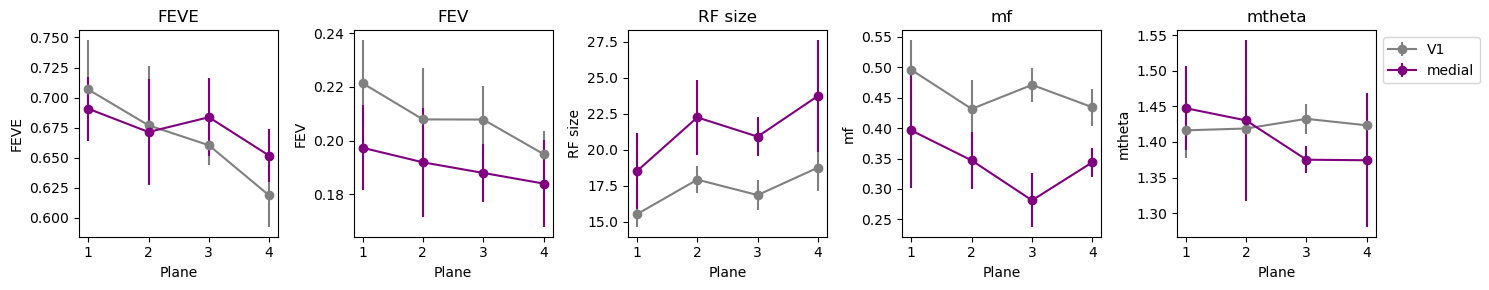

In [ ]:
plane_vars = [feve_plane, fev_plane, rfsize_plane, mf_plane, mtheta_plane]
var_names = ['FEVE', 'FEV', 'RF size', 'mf', 'mtheta']
nvar = len(plane_vars)
fig, ax = plt.subplots(1, nvar, figsize=(nvar*3, 3))
for ivar in range(nvar):
    ax[ivar].errorbar(np.arange(1, 5), np.nanmean(plane_vars[ivar][0], axis=0), yerr=np.nanstd(plane_vars[ivar][0], axis=0), label='V1', marker='o', color='gray')
    ax[ivar].errorbar(np.arange(1, 5), np.nanmean(plane_vars[ivar][1], axis=0), yerr=np.nanstd(plane_vars[ivar][1], axis=0), label='medial', marker='o', color='purple')
    ax[ivar].set_title(f'{var_names[ivar]}')
    ax[ivar].set_xlabel('Plane')
    ax[ivar].set_ylabel(var_names[ivar])
    ax[ivar].set_xticks(np.arange(1, 5))
#  legend outside the plot
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()

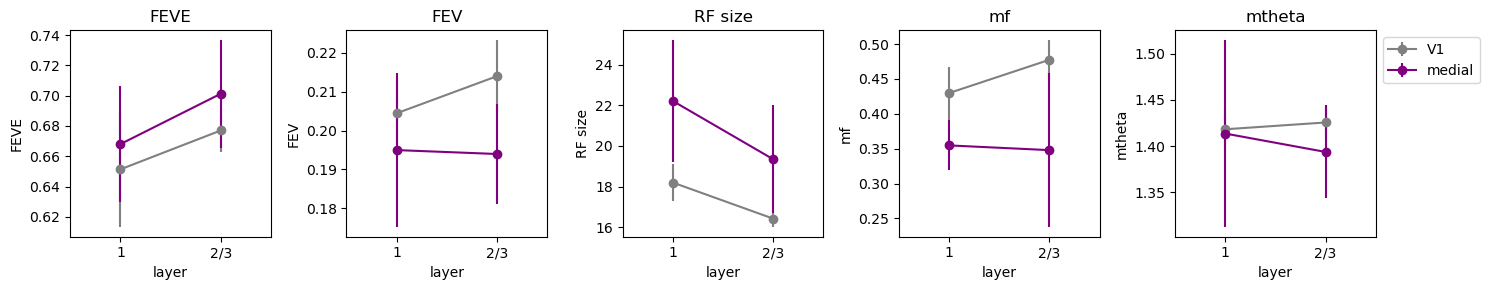

In [ ]:
plane_vars = [feve_plane, fev_plane, rfsize_plane, mf_plane, mtheta_plane]
var_names = ['FEVE', 'FEV', 'RF size', 'mf', 'mtheta']
nvar = len(plane_vars)
fig, ax = plt.subplots(1, nvar, figsize=(nvar*3, 3))
for ivar in range(nvar):
    ax[ivar].errorbar(np.arange(1, 3), np.nanmean(plane_vars[ivar][0], axis=0), yerr=np.nanstd(plane_vars[ivar][0], axis=0), label='V1', marker='o', color='gray')
    ax[ivar].errorbar(np.arange(1, 3), np.nanmean(plane_vars[ivar][1], axis=0), yerr=np.nanstd(plane_vars[ivar][1], axis=0), label='medial', marker='o', color='purple')
    ax[ivar].set_title(f'{var_names[ivar]}')
    ax[ivar].set_xlabel('layer')
    ax[ivar].set_ylabel(var_names[ivar])
    ax[ivar].set_xticks(np.arange(1, 3))
    ax[ivar].set_xticklabels(['1', '2/3'])
    ax[ivar].set_xlim([0.5, 2.5])
#  legend outside the plot
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()

p-value for FEV: 0.0045


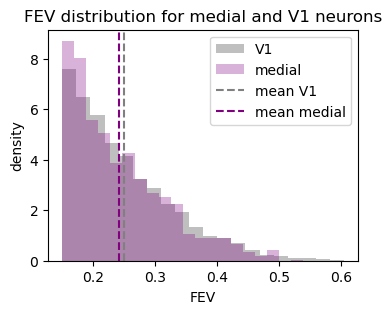

In [ ]:
# plot the distribution of fev
fig, ax = plt.subplots(1, 1, figsize=(4, 3))
ax = [ax]
ax[0].hist(fev_all[0], bins=20, alpha=0.5, label='V1', color='gray', density=True)
ax[0].hist(fev_all[1], bins=20, alpha=0.3, label='medial', color='purple', density=True)
# stats test for two distributions with different sample sizes
from scipy import stats
t_stat, p_value = stats.ttest_ind(fev_all[0], fev_all[1], equal_var=False)
print(f'p-value for FEV: {p_value:.4f}')
# plot the mean and std
ax[0].axvline(np.mean(fev_all[0]), color='gray', linestyle='--', label='mean V1')
ax[0].axvline(np.mean(fev_all[1]), color='purple', linestyle='--', label='mean medial')
ax[0].set_xlabel('FEV')
ax[0].set_ylabel('density')
ax[0].set_title('FEV distribution for medial and V1 neurons')
ax[0].legend()

p-value for rfsize: 0.0000


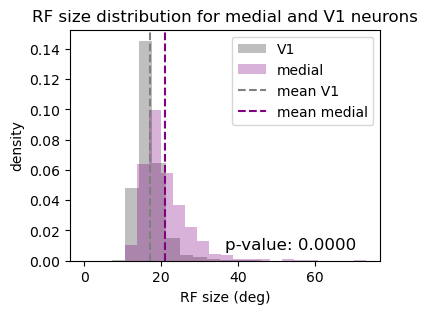

In [ ]:
# plot the distribution of fev
fig, ax = plt.subplots(1, 1, figsize=(4, 3))
ax = [ax]
ax[0].hist(rfsize_all[0], bins=20, alpha=0.5, label='V1', color='gray', density=True)
ax[0].hist(rfsize_all[1], bins=20, alpha=0.3, label='medial', color='purple', density=True)
# stats test for two distributions with different sample sizes
from scipy import stats
t_stat, p_value = stats.ttest_ind(rfsize_all[0], rfsize_all[1], equal_var=False)
print(f'p-value for rfsize: {p_value:.4f}')
# plot the mean and std
ax[0].axvline(np.mean(rfsize_all[0]), color='gray', linestyle='--', label='mean V1')
ax[0].axvline(np.mean(rfsize_all[1]), color='purple', linestyle='--', label='mean medial')
ax[0].set_xlabel('RF size (deg)')
ax[0].set_ylabel('density')
ax[0].set_title('RF size distribution for medial and V1 neurons')
ax[0].text(0.5, 0.1, f'p-value: {p_value:.4f}', transform=ax[0].transAxes, fontsize=12, verticalalignment='top')
ax[0].legend()

In [ ]:
mf_all[0].shape

(5495,)

p-value for mf: 0.0000
p-value for mtheta: 0.6379


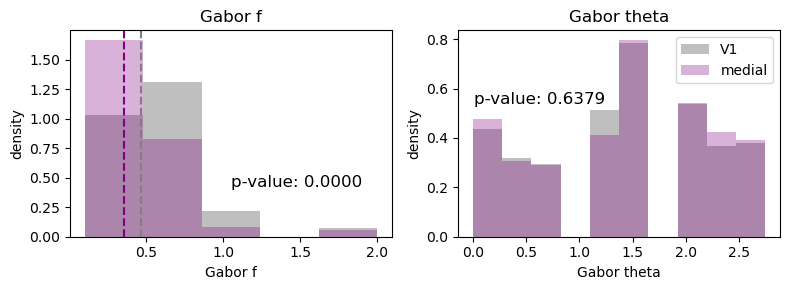

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3))
# gabor mf and mtheta distribution
ax[0].hist(mf_all[0], bins=5, alpha=0.5, label='V1', color='gray', density=True)
ax[0].hist(mf_all[1], bins=5, alpha=0.3, label='medial', color='purple', density=True)
# stats test for two distributions with different sample sizes
t_stat, p_value = stats.ttest_ind(mf_all[0], mf_all[1], equal_var=False)
print(f'p-value for mf: {p_value:.4f}')
# plot the mean and std
ax[0].axvline(np.mean(mf_all[0]), color='gray', linestyle='--', label='mean V1')
ax[0].axvline(np.mean(mf_all[1]), color='purple', linestyle='--', label='mean medial')
ax[0].set_xlabel('Gabor f')
ax[0].set_ylabel('density')
ax[0].set_title('Gabor f')
ax[0].text(0.5, 0.3, f'p-value: {p_value:.4f}', transform=ax[0].transAxes, fontsize=12, verticalalignment='top')
# gabor mtheta distribution
ax[1].hist(mtheta_all[0], bins=10, alpha=0.5, label='V1', color='gray', density=True)
ax[1].hist(mtheta_all[1], bins=10, alpha=0.3, label='medial', color='purple', density=True)
# stats test for two distributions with different sample sizes
t_stat, p_value = stats.ttest_ind(mtheta_all[0], mtheta_all[1], equal_var=False)
print(f'p-value for mtheta: {p_value:.4f}')
# plot the mean and std
# ax[1].axvline(np.mean(mtheta_all[0]), color='gray', linestyle='--', label='mean V1')
# ax[1].axvline(np.mean(mtheta_all[1]), color='purple', linestyle='--', label='mean medial')
ax[1].set_xlabel('Gabor theta')
ax[1].set_ylabel('density')
ax[1].set_title('Gabor theta')
ax[1].text(0.05, 0.7, f'p-value: {p_value:.4f}', transform=ax[1].transAxes, fontsize=12, verticalalignment='top')
ax[1].legend()
plt.tight_layout()


# pooling size

# medial model
- compare FEVE with the fullmodel and the medial model
- visualize the first layer
- Does increase the #layer change the FEVE? try 64x64 model, 64x64x64 model and 64x64x64x64 model
- also the #kernels change the FEVE? compare the 16-320 vs 64x64 model